# Molecular Enumeration Benchmark Analysis

This notebook provides a comprehensive analysis of different molecular enumeration methods including HEALER, ChemProjector, Synformer, and REINVENT across multiple datasets.

In [1]:
# imports
import sys
import os
import inspect
import healer
module_path = inspect.getfile(healer)
os.chdir(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.abspath(os.path.join('external')))

import glob
import base64
import re
from IPython.display import HTML, SVG, display
from itertools import product

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from tqdm import tqdm

from external.HamDiv import diversity as hamdiv
from prop_profiler.profiler import profile_molecules
from healer.utils import utils

# FP generator with same parameters as in the HEALER class
fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=3, fpSize=2048, includeChirality=True
)


Failed to patch pandas - PandasTools will have limited functionality


## Helper Functions

These functions are used to process and analyze the enumeration results, including data loading, statistical calculations, and visualization. Run the cells below to define the helper functions that will be used throughout the analysis.

The helper functions are split into several categories:
- **Utility Functions**: General-purpose functions for data manipulation and calculations.
- **Data Processing Functions**: Functions to unify and process enumeration results from different methods.
- **Statistical Analysis Functions**: Functions to calculate performance metrics such as similarity, diversity, and enumeration success rates.
- **Molecular Property Analysis Functions**: Functions to analyze drug-likeness and optimization metrics like QED, CNS-MPO, and Stoplight scores.
- **Visualization Functions**: Functions to create plots and visualizations for the analysis results.

### Utility Functions

Helper functions for diversity calculations, matrix operations, and data transformations.

Following functions are included in this section:
- `get_top_n_subset()`: Returns the top N rows of a DataFrame based on a specified column.
- `run_profiler()`: Runs molecular profiling to calculate various molecular properties including QED, CNS-MPO, and Stoplight scores.
- `get_diversity_score()`: Calculates the diversity score for a set of molecules based on pairwise Jaccard distance.
- `get_pdist_matrix()`: Computes the pairwise distance matrix for a set of molecules using RDKit.
- `min_max_normalize()`: Normalizes a numpy array to the range [0, 1].

In [2]:
## Utility Functions
def get_top_n_subset(data: pd.DataFrame, n=100) -> pd.DataFrame:
    '''
        Get the top n enumerations from the DataFrame, including the query molecules. 
        This will drop duplicates in each query enumeration.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to retrieve. Default is 100.

        Returns:
            pd.DataFrame: A DataFrame containing the top n enumerations plus the query molecules.
                The output will include the following columns:
                    - 'ID': Unique identifier for the enumerated compound as in healer.
                    - 'Product': SMILES of the enumerated compound.
                    - 'num_steps': Number of steps taken to enumerate the compound.
                    - 'Similarity_to_query': Similarity of the enumerated compound to the query compound.
                    - 'df_id': Identifier for the DataFrame from which the enumeration was generated.
    '''
    return data.drop_duplicates(subset=['df_id', 'Product']).groupby('df_id').head(n+1).reset_index(drop=True)

def run_profiler(data: pd.DataFrame, device='cuda', verbose=False) -> pd.DataFrame:
    '''
        Run the molecule profiler on the given DataFrame along with the SA score calculation.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            device (str): The device to run the profiler on. Default is 'cuda'.
            verbose (bool): Whether to print verbose output. Default is False.

        Returns:
            pd.DataFrame: A DataFrame containing the profiling results.
    '''
    data['SA_score'] = data['Product'].apply(lambda x: utils.get_sascore(x))
    prop_data = profile_molecules(data['Product'].to_list(), device=device, verbose=verbose)
    prop_data = prop_data.rename(columns={'smiles': 'Product'})
    data = pd.merge(
        data, prop_data, how='left', on='Product'
    )
    return data

def get_diversity_score(smiles, mode='HamDiv'):
    '''
        Calculate the diversity score of a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.
            mode (str): The method to calculate diversity. Options are
                HamDiv, FG, RS, BM, Richness, IntDiv, SumDiv, Diam, SumDiam,
                Bot, SumBot, DPP, and NCircles-0.x.

        Returns:
            float: The diversity score.
    '''
    if mode in ['FG', 'RS', 'BM', 'Richness']:
        return hamdiv.diversity_all(smiles, mode=mode)
    
    dists = get_pdist_matrix(smiles)
    if mode == 'HamDiv':
        n = len(smiles)
        comp_method = 'exact_dp' if n <= 5 else 'local_search' if n <= 20 else 'greedy_tsp'
        return hamdiv.HamDiv(smiles, dists=dists, method=comp_method)
    
    return hamdiv.diversity_all(smiles, dists=dists, mode=mode)

def get_pdist_matrix(smiles):
    '''
        Calculate the pairwise distance matrix for a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.

        Returns:
            np.ndarray: The pairwise distance matrix.
    '''
    fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in smiles]
    sims = np.zeros((len(smiles), len(smiles)))
    for i in range(len(smiles)):
        sims[i] = Chem.DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    return 1 - sims

def min_max_normalize(arr):
    '''
        Min-max normalization of an array.

        Args:
            arr (np.ndarray): The array to be normalized.

        Returns:
            np.ndarray: The normalized array.
    '''
    arr = np.array(arr)
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    return (arr - arr_min) / (arr_max - arr_min)


### Statistical Analysis Functions

Functions for calculating various performance metrics including similarity, diversity, and enumeration success rates.

Following functions are included in this section:
- `calc_ser()`: Calculates the Successful Enumeration Rate (SER) for the enumerated compounds.
- `calc_rr()`: Calculates the Reconstruction Rate (RR) for the enumerated compounds.
- `calc_top_n_average_sims()`: Calculates the average similarities for the top N compounds for each query enumeration.
- `calc_top_n_diversities()`: Calculates the diversities for the top N compounds for each query enumeration.
- `calc_top_n_average_num_steps()`: Calculates the average number of steps for the top N compounds for each query enumeration.
- `get_summary_stats()`: Computes summary statistics for the enumeration results using the above functions.

In [4]:
## Statistical Analysis Functions
def calc_ser(data: pd.DataFrame) -> float:
    '''
        Calculate the Successful Enumeration Rate (SER) for the enumerated compounds.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.

        Returns:
            float: The Successful Enumeration Rate (SER) calculated as the ratio of 
                successful enumerations to total enumerations.
    '''
    successful_enums = len(data[data['ID'] == 'HEAL_000001'])
    total_enums = len(data[data['ID'] == 'HEAL_000000'])
    return successful_enums / total_enums
    
def calc_rr(data: pd.DataFrame) -> float:
    '''
        Calculate the Reconstruction Rate (RR) for the enumerated compounds.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.

        Returns:
            float: The Reconstruction Rate (RR) calculated as the ratio of 
                successfully reconstructed enumerations to total enumerations.
    '''
    enums = data[data['ID'] == 'HEAL_000001']
    successful_reconstructions = len(enums[enums['Similarity_to_query'] == 1.0])
    total_enums = len(data[data['ID'] == 'HEAL_000000'])
    return successful_reconstructions / total_enums

def calc_top_n_average_sims(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the average similarity of the top n enumerations to the query.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the average similarity of the top n 
                enumerations to the query for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_sims = top_n_data.groupby('df_id')['Similarity_to_query'].apply(
        lambda x: x.iloc[1:].mean() if len(x) > 1 else np.nan
    )
    return avg_sims.to_numpy()

def calc_top_n_diversities(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the diversity of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the diversity of the top n 
                enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    divs = top_n_data.groupby('df_id')['Product'].apply(
        lambda x: get_diversity_score(x.iloc[1:].tolist(), mode='HamDiv') if len(x) > 1 else 0
    )
    return divs.to_numpy()

def calc_top_n_average_num_steps(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the average number of reaction steps for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the average number of reaction steps 
                for the top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_steps = top_n_data.groupby('df_id')['num_steps'].apply(lambda x: x.iloc[1:].mean() if len(x) > 1 else np.nan)
    return avg_steps.to_numpy()

def get_summary_stats(data: pd.DataFrame, n=[1, 5, 10, 25]) -> dict:
    '''
        Get summary statistics for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (list): A list of integers representing the number of top enumerations to consider.
                Default is [1, 5, 10, 25].

        Returns:
            dict: A dictionary containing the summary statistics for each n in the list.
                The keys:
                    - 'Top-n Average Similarity': Average similarity of the top n enumerations to the query
                    - 'Top-n Average Diversity': Average diversity of the top n enumerations
                    - 'Top-n Average Number of Steps': Average number of reaction steps for the top n enumerations
    '''
    summary_stats = {}
    for top_n in tqdm(n, desc='Calculating summary statistics', total=len(n)):
        summary_stats[f'Top-{top_n} Average Similarity'] = np.nanmean(calc_top_n_average_sims(data, n=top_n))
        summary_stats[f'Top-{top_n} Average Diversity'] = np.nanmean(calc_top_n_diversities(data, n=top_n))
        summary_stats[f'Top-{top_n} Average Number of Steps'] = np.nanmean(calc_top_n_average_num_steps(data, n=top_n))

    return summary_stats


### Molecular Property Analysis Functions

Functions for calculating drug-likeness and optimization metrics including QED, CNS-MPO, and Stoplight scores.

Following functions are included in this section:
- `calc_top_n_max_qed_improvements()`: Calculates the maximum QED improvements for the top N compounds for each query enumeration.
- `calc_top_n_max_cns_mpo_improvements()`: Calculates the maximum CNS-MPO improvements for the top N compounds for each query enumeration.
- `calc_top_n_max_stoplight_improvements()`: Calculates the maximum Stoplight score improvements for the top N compounds for each query enumeration.
- `calc_top_n_stoplight_color_changes()`: Calculates the Stoplight color changes for the top N compounds for each query enumeration.
- `get_top_n_optimization_stats()`: Computes optimization statistics for the enumeration results using the above functions.

In [5]:
## Molecular Property Analysis Functions
def calc_top_n_max_qed_improvements(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the max QED improvements of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the max QED improvements of the 
                top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_qed_improvements = top_n_data.groupby('df_id')['qed'].apply(
        lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
    )
    return avg_qed_improvements.to_numpy()

def calc_top_n_max_cns_mpo_improvements(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the max CNS-MPO improvements of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the max CNS-MPO improvements of the 
                top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_cns_mpo_improvements = top_n_data.groupby('df_id')['cns_mpo_score'].apply(
        lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
    )
    return avg_cns_mpo_improvements.to_numpy()

def calc_top_n_max_stoplight_improvements(data: pd.DataFrame, n=100) -> np.ndarray:
    '''
        Calculate the max stoplight score improvements of the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            np.ndarray: An array containing the max stoplight score improvements of the 
                top n enumerations for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    avg_stoplight_improvements = top_n_data.groupby('df_id')['stoplight_score'].apply(
        lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
    )
    return avg_stoplight_improvements.to_numpy()

def calc_top_n_stoplight_color_changes(data: pd.DataFrame, n=100) -> dict:
    '''
        Calculate the stoplight color changes for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            dict: A dictionary containing the stoplight color changes for each query molecule.
    '''
    top_n_data = get_top_n_subset(data, n=n)
    stoplight_changes = {
        'red2green': [], 'red2yellow': [], 'red2red': [],
        'yellow2green': [], 'yellow2yellow': [], 'yellow2red': [],
        'green2green': [], 'green2yellow': [], 'green2red': []
    }
    for df_id, group in top_n_data.groupby('df_id'):
        stoplight_colors = group['stoplight_color'].values
        query_color = stoplight_colors[0]
        n = len(stoplight_colors)
        if query_color == 'red':
            stoplight_changes['red2green'].append(
                len([1 for x in stoplight_colors[1:] if x == 'green']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['red2yellow'].append(
                len([1 for x in stoplight_colors[1:] if x == 'yellow']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['red2red'].append(
                len([1 for x in stoplight_colors[1:] if x == 'red']) / (n - 1) if n > 1 else np.nan
            )
        elif query_color == 'yellow':
            stoplight_changes['yellow2green'].append(
                len([1 for x in stoplight_colors[1:] if x == 'green']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['yellow2yellow'].append(
                len([1 for x in stoplight_colors[1:] if x == 'yellow']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['yellow2red'].append(
                len([1 for x in stoplight_colors[1:] if x == 'red']) / (n - 1) if n > 1 else np.nan
            )
        elif query_color == 'green':
            stoplight_changes['green2green'].append(
                len([1 for x in stoplight_colors[1:] if x == 'green']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['green2yellow'].append(
                len([1 for x in stoplight_colors[1:] if x == 'yellow']) / (n - 1) if n > 1 else np.nan
            )
            stoplight_changes['green2red'].append(
                len([1 for x in stoplight_colors[1:] if x == 'red']) / (n - 1) if n > 1 else np.nan
            )

    for key in stoplight_changes:
        stoplight_changes[key] = np.nanmean(stoplight_changes[key])
    return stoplight_changes

def get_top_n_optimization_stats(data: pd.DataFrame, n=100) -> dict:
    '''
        Get optimization statistics for the top n enumerations.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (int): The number of top enumerations to consider. Default is 100.

        Returns:
            dict: A dictionary containing the QED, Stoplight and CNS-MPO statistics for each n in the list.
                The keys:
                    - 'Top-n Average QED': Average QED of the top n enumerations
                    - 'Top-n Average Stoplight': Average Stoplight of the top n enumerations
                    - 'Top-n Average CNS-MPO': Average CNS-MPO of the top n enumerations
                    - All stoplight color changes for the top n enumerations
    '''
    optimization_stats = {}
    optimization_stats[f'Top-{n} Average of Max QED Improvements'] = np.nanmean(calc_top_n_max_qed_improvements(data, n=n))
    optimization_stats[f'Top-{n} Average of Max Stoplight Improvements'] = np.nanmean(calc_top_n_max_stoplight_improvements(data, n=n))
    optimization_stats[f'Top-{n} Average of Max CNS-MPO Improvements'] = np.nanmean(calc_top_n_max_cns_mpo_improvements(data, n=n))
    optimization_stats.update(calc_top_n_stoplight_color_changes(data, n=n))

    return optimization_stats


### Data Processing Functions

These functions handle the conversion of different enumeration result formats into a unified format for comparison.

Following functions are included in this section:
- `unify_result_formats()`: Unifies the result formats from different enumeration methods into a consistent format for comparison.
- `find_best_subset_file()`: Finds the best subset file if it is saved in the results directory.
- `process_enumeration_file()`: Processes the enumeration file to extract relevant data, convert to unified format and compute necessary statistics for analysis.

In [6]:
## Data Processing Functions
def unify_result_formats(df: pd.DataFrame, incoming_frmt: str) -> pd.DataFrame:
    '''
        Unify the result format of different methods.

        Args:
            df: DataFrame containing the enumerated compounds.
            incoming_frmt: Format of the incoming DataFrame.
                Options are:
                    - healer
                    - chemprojector
                    - synformer
                    - reinvent

        Returns:
            pd.DataFrame: DataFrame in Healer's result format. The output will include the following columns:
                - 'Product': SMILES of the enumerated compound.
                - 'num_steps': Number of steps taken to enumerate the compound.
                - 'Similarity_to_query': Similarity of the enumerated compound to the query compound.
                - 'ID': Unique identifier for the enumerated compound as in healer.
                - 'df_id': Identifier for the DataFrame from which the enumeration was generated.
    '''
    def _clc_sims(query_smi, product_smis):
        query_fp = fp_generator.GetFingerprint(Chem.MolFromSmiles(query_smi))
        product_fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(mol)) for mol in product_smis]
        return np.round(Chem.DataStructs.BulkTanimotoSimilarity(query_fp, product_fps), 2)
    
    def _assign_ids(group, df_id):
        group = group.copy()
        group['ID'] = [f'HEAL_{i:06d}' for i in range(len(group))]
        group['df_id'] = df_id
        return group
    
    if incoming_frmt in ['chemprojector', 'synformer']:
        targets = df['target'].unique().tolist()
        def _process_group(group):
            target = group.name
            group = group.copy()
            group['Similarity_to_query'] = _clc_sims(target, group['smiles'].values)
            group = group[['smiles', 'num_steps', 'Similarity_to_query']].sort_values(
                by='Similarity_to_query', ascending=False
            ).reset_index(drop=True)
            query_df = pd.DataFrame({
                'smiles': [target],
                'num_steps': [0],
                'Similarity_to_query': [1.0]
            })
            result = pd.concat([query_df, group], axis=0).reset_index(drop=True)
            result = _assign_ids(result, df_id=targets.index(target))
            return result
        
        df = df.groupby('target', group_keys=False).apply(_process_group, include_groups=False)
        df = df.rename(columns={'smiles': 'Product'})
        return df[['ID', 'Product', 'num_steps', 'Similarity_to_query', 'df_id']].reset_index(drop=True)
    
    elif incoming_frmt == 'reinvent':
        targets = df['Input_SMILES'].unique().tolist()
        def _process_group(group):
            target = group.name
            group = group.copy()
            group['Similarity_to_query'] = _clc_sims(target, group['SMILES'].values)
            group = group[['SMILES', 'Similarity_to_query']].sort_values(
                by='Similarity_to_query', ascending=False
            ).reset_index(drop=True)
            query_df = pd.DataFrame({
                'SMILES': [target],
                'Similarity_to_query': [1.0]
            })
            result = pd.concat([query_df, group], axis=0).reset_index(drop=True)
            result = _assign_ids(result, df_id=targets.index(target))
            return result
            
        df = df.groupby('Input_SMILES', group_keys=False).apply(_process_group, include_groups=False)
        df = df.rename(columns={'SMILES': 'Product'})
        df['num_steps'] = 9  # Reinvent does not provide num_steps, so we set it to 9
        return df[['ID', 'Product', 'num_steps', 'Similarity_to_query', 'df_id']].reset_index(drop=True)

    elif incoming_frmt == 'healer':
        rxn_cols = [col for col in df.columns if col.startswith('Reaction')]
        rxn_cols = df[rxn_cols]
        num_steps = (~pd.isna(rxn_cols)).sum(axis=1)
        df['num_steps'] = num_steps
        targets_df = df[df['ID'] == 'HEAL_000000']
        df_ids = []
        for i in range(len(targets_df)):
            start_idx = targets_df.index[i]
            end_idx = targets_df.index[i + 1] if i + 1 < len(targets_df) else len(df)
            df_ids.extend([i] * (end_idx - start_idx))
        
        df['df_id'] = df_ids
        return df[['ID', 'Product', 'num_steps', 'Similarity_to_query', 'df_id']].reset_index(drop=True)
    
    else:
        raise ValueError(f"Unknown incoming format: {incoming_frmt}. Supported formats are: 'chemprojector', 'synformer', 'healer'.")

def find_best_subset_file(base_file_path, required_n):
    """
        Find the best existing subset file that has >= required_n samples.
        
        Args:
            base_file_path: Original file path (e.g., 'benchmark/results/healer/enamine_1k_random_enums.csv')
            required_n: Minimum number of samples needed
        
        Returns:
            tuple: (file_path, actual_n) if found, (None, None) if not found
    """
    directory = os.path.dirname(base_file_path)
    base_name = os.path.basename(base_file_path).replace('.csv', '')
    
    pattern = os.path.join(directory, f"{base_name}_subset*.csv")
    subset_files = glob.glob(pattern)
    
    suitable_files = []
    for file_path in subset_files:
        match = re.search(r'_subset(\d+)\.csv$', file_path)
        if match:
            n = int(match.group(1))
            if n >= required_n:
                suitable_files.append((file_path, n))
    
    if suitable_files:
        suitable_files.sort(key=lambda x: x[1])  # Sort by n
        return suitable_files[0]
    
    return None, None

def process_enumeration_file(
        file_path, incoming_format, sim_cutoff=0.3, 
        top_n_partitions=[1, 5, 10, 25, 50, 100],
        overwrite_subset=False, device='cuda', verbose=True
    ) -> tuple:
    """
        Process enumeration results file: load, unify format, filter, and create subset with profiling.
        
        Args:
            file_path: Path to the enumeration results CSV file
            incoming_format: Format of the input file ('healer', 'chemprojector', 'synformer', 'reinvent')
            sim_cutoff: Minimum similarity threshold for filtering
            top_n_partitions: List of integers specifying the top n enumerations to consider for summary statistics
            overwrite_subset: Whether to overwrite existing subset files
            device: Device for profiling ('cuda' or 'cpu')
            verbose: Whether to show verbose output during profiling
        
        Returns:
            tuple: (subset_dataframe, summary_stats, optimization_stats)
    """
    if incoming_format == 'healer':
        healer_dtypes = {
            'ID': str, 'Product': str, 
            'BB1': str, 'BB2': str, 'BB3': str, 'BB4': str,
            'Reaction1_name': str, 'Reaction2_name': str, 'Reaction3_name': str,
            'URL1': str, 'URL2': str, 'URL3': str, 'URL4': str,
            'Similarity_to_query': float
        }
        enums = pd.read_csv(file_path, dtype=healer_dtypes)
    else:
        enums = pd.read_csv(file_path)
    
    # Unify format and filter
    unified_enums = unify_result_formats(enums, incoming_frmt=incoming_format)
    unified_enums = unified_enums[unified_enums['Similarity_to_query'] > sim_cutoff].reset_index(drop=True)
    
    # Check for existing subset file or create new one
    top_n_partitions = sorted(top_n_partitions)
    top_n = top_n_partitions[-1]
    best_subset_path, actual_n = find_best_subset_file(file_path, top_n)
    
    if best_subset_path is None or overwrite_subset:
        subset_data = get_top_n_subset(unified_enums, n=top_n)
        subset_data = run_profiler(subset_data, device=device, verbose=verbose)
        subset_file_path = file_path.replace('.csv', f'_subset{top_n}.csv')
        subset_data.to_csv(subset_file_path, index=False)
    else:
        # Use existing file and trim if necessary
        subset_data = pd.read_csv(best_subset_path)
        if actual_n > top_n:
            subset_data = get_top_n_subset(subset_data, n=top_n)
    
    # Calculate statistics
    summary_stats = {'SER': calc_ser(unified_enums), 'RR': calc_rr(unified_enums)}
    summary_stats.update(get_summary_stats(subset_data, n=top_n_partitions))
    opt_stats = get_top_n_optimization_stats(subset_data, n=top_n)
    
    return subset_data, summary_stats, opt_stats


### Visualization Functions

Functions for creating distribution plots, statistical visualizations, and molecular structure displays.

Following functions are included in this section:
- `highlight_extremes()`: Highlights the extremes (min or max) in a DataFrame row for styling in HTML output.
- `plot_metric()`: Plot a grouped bar chart for a specific metric across different enumeration methods.
- `kde_plot()`: Plot a kernel density estimate (KDE) line for a given data.
- `plot_distributions()`: Plot the distributions of given arrays on the specified axes.
- `significance_test()`: Perform a significance test (t-test) between the query and enumerated compounds for a specific metric.
- `plot_drug_likeliness_profiles`: Plot the drug-likeliness scores (QED, CNS-MPO and Stoplight) for the enumerations.
- `display_svg_mol`: Utility function to display SVG strings of molecules in Jupyter notebooks.
- `display_svg_grid`: Utility function to display a grid of SVG images in Jupyter notebooks.

In [7]:
## Helper Visualization Functions
def highlight_extremes(row, min_rows):
    '''
        Highlight the extremes (min or max) in a DataFrame row for styling in HTML output.

        Args:
            row (pd.Series): A row of the DataFrame to be styled.
            min_rows (set): A set of row names that should be highlighted with minimum values.

        Returns:
            pd.Series: A Series with styles applied to the row, where cells with min or max values are bolded.
    '''
    styles = pd.Series("", index=row.index)
    prefer_min = row.name in min_rows

    # iterate over each Dataset group
    for ds in row.index.get_level_values(0).unique():
        sub = row[ds]  # Series indexed by Method
        target_value = sub.min() if prefer_min else sub.max()
        # bold all cells equal to the target
        mask = sub == target_value
        for method in sub.index:
            if mask.loc[method]:
                styles[(ds, method)] = "font-weight: bold"

    return styles

def plot_metric(ax, df_metric):
    '''
        Plot a grouped bar chart for a given metric DataFrame.

        Args:
            ax (matplotlib.axes.Axes): The axes to plot on.
            df_metric (pd.DataFrame): DataFrame containing the metric data with columns:
                - 'Dataset': Name of the dataset
                - 'Method': Name of the method
                - 'Value': Value of the metric
                - 'Statistic': Name of the statistic being plotted
    '''
    # Draw grouped bars with seaborn
    sns.barplot(
        data=df_metric,
        x='Dataset',
        y='Value',
        hue='Method',
        ax=ax,
    )
    # Title & labels
    ax.set_title(df_metric['Statistic'].iloc[0])
    ax.set_ylabel("Value")
    ax.set_xlabel("")  # keep x-label clean

def kdeplot(data, line_number, **kwargs):
    '''
        Plot a kernel density estimate (KDE) for the given data.

        Args:
            data (pd.Series or np.ndarray): The data to plot.
            line_number (int): The index of the line to normalize.
            **kwargs: Additional keyword arguments for seaborn's kdeplot.

        Returns:
            matplotlib.axes.Axes: The axes object with the KDE plot.
    '''
    ax = sns.kdeplot(data, linewidth=2, **kwargs)
    if 'fill' in kwargs.keys() and kwargs['fill']==True:
        path = ax.collections[line_number].get_paths()
        ys = min_max_normalize(path[0].vertices[:, 1])
        path[0].vertices[:, 1] = ys
    else:
        line = ax.lines[line_number]
        line.set_ydata(min_max_normalize(line.get_ydata()))
    ax.set_ylim(0, 1.05)       
    ax.autoscale_view()
    return ax

def plot_distributions(arrays, labels, ax, metric_name, normalize_y=True, title=None, sec_ylabel=None, annotate_n=True):
    '''
        Plot the distributions of the given arrays on the specified axes. 

        Args:
            arrays (list of np.ndarray): List of arrays to plot.
            labels (list of str): List of labels for each array.
            ax (matplotlib.axes.Axes): The axes to plot on.
            metric_name (str): Name of the metric being plotted.
            normalize_y (bool): Whether to normalize the y-axis. Default is True.
            title (str): Title for the plot. Default is None.
            sec_ylabel (str): Secondary y-axis label. Default is None.
            annotate_n (bool): Whether to annotate the number of samples for each distribution. Default is True.

        Returns:
            None
    '''
    if normalize_y:
        for i, (arr, label) in enumerate(zip(arrays, labels)):
            alpha = 0.1 if label != 'Query' else 0.8
            kdeplot(arr, i, color=f'C{i}', label=label, alpha=alpha, fill=True, ax=ax)
    else:
        for i, (arr, label) in enumerate(zip(arrays, labels)):
            alpha = 0.1 if label != 'Query' else 0.8
            sns.kdeplot(arr, color=f'C{i}', label=label, alpha=alpha, fill=True, ax=ax, linewidth=2)
    # annotate number of samples for each distribution
    if annotate_n:
        for i, (arr, label) in enumerate(zip(arrays, labels)):
            ax.annotate(f'n={len(arr)}', xy=(0.70, 0.95-(i*0.075)), xycoords='axes fraction', fontsize=12,
                        ha='left', va='center', color=f'C{i}')
    ax.set_title(f'{title}', fontsize=18)
    ax.set_xlabel(metric_name)
    ax.set_ylabel('Normalized Density')
    if sec_ylabel:
        secax = ax.secondary_yaxis('right')
        secax.set_ylabel(sec_ylabel, fontsize=18, rotation=270, labelpad=20)
        secax.set_yticks([]); secax.set_yticklabels([])
    ax.legend()

def significance_test(data_arrays, distribution_labels):
    '''
        Perform significance testing (T-test) between the query distribution and other distributions.

        Args:
            data_arrays (list of np.ndarray): List of arrays containing the distributions to compare.
            distribution_labels (list of str): List of labels for each distribution.

        Returns:
            list: A list of strings summarizing the T-test results for each comparison.
                Each string contains the T-statistic, p-value, and significance level.
                Significance levels are indicated as follows:
                    - 'ns' for p-value > 0.05 (not significant)
                    - '*' for 0.01 < p-value <= 0.05 (significant)
                    - '**' for 0.001 < p-value <= 0.01 (highly significant)
                    - '***' for p-value <= 0.001 (very highly significant
    '''
    query_vals = data_arrays[0]
    res = []
    for i in range(1, len(data_arrays)):
        t_stat, t_pval = ttest_ind(query_vals, data_arrays[i], alternative='greater')
        sign_level = 'ns' if t_pval > 0.05 else '*' if 0.01 < t_pval <= 0.05 else '**' if 0.001 < t_pval <= 0.01 else '***'
        res.append(f"T-test: {distribution_labels[i]} vs Query: statistic={t_stat:.4f}, p-value={t_pval:.4f} ({sign_level})")
    return res

def plot_drug_likeliness_profiles(input_file=None, data=None, ax=None, include_colorbar=True):
    '''
        Plot the drug-likeliness profiles of enumerated molecules.

        Args:
            input_file (str): The file containing the enumerated molecules with properties.
                If provided, this file will be read to extract the data.
            data (pd.DataFrame): If provided, this DataFrame will be used directly instead of reading from a file.
            ax (matplotlib.axes.Axes): If provided, the plot will be drawn on this axis; otherwise, a new figure will be created.
            include_colorbar (bool): Whether to include a colorbar for the stoplight score. Default is True.

        Returns:
            matplotlib.figure.Figure or matplotlib.axes.Axes: The figure or axes containing the plot.
    '''
    if data is None:
        data = pd.read_csv(input_file)
    data = data.dropna(subset=['cns_mpo_score', 'qed', 'stoplight_color']).reset_index(drop=True)
    data['plot_color'] = data['stoplight_color'].apply(lambda x: 'gold' if x == 'yellow' else x)
    query_molecule = data[data['ID'] == 'HEAL_000000'].reset_index(drop=True)
    data = data[data['ID'] != 'HEAL_000000']
    n = len(data)

    # plot the enumeration profiles
    return_fig = False
    if ax is None:
        fig = plt.figure(figsize=(10, 8), dpi=150)
        ax = fig.add_subplot(111)
        return_fig = True
    stoplight_cmap = mpl.colors.ListedColormap(['red', 'gold', 'green'])
    stoplight_norm = mpl.colors.BoundaryNorm(np.linspace(0, 3, 4), stoplight_cmap.N)

    y_jitter = np.random.normal(0, 0.02, (n,)) * np.array([0] + [1] * (n - 1))
    ax.scatter(data['qed'], data['cns_mpo_score']+y_jitter, 
                c=data['plot_color'], alpha=0.5, s=100)
    ax.scatter(query_molecule['qed'], query_molecule['cns_mpo_score'], edgecolors='blue', 
                facecolors=query_molecule['stoplight_color'], s=750,
                marker=mpl.markers.MarkerStyle(marker='*', fillstyle='full'), linewidths=2.5
                )

    # add colorbar for stoplight color
    if include_colorbar:
        cbar = plt.colorbar(mpl.cm.ScalarMappable(cmap=stoplight_cmap, norm=stoplight_norm), ax=ax)
        cbar.set_ticks([0.5, 1.5, 2.5])
        cbar.set_ticklabels(['Bad', 'Average', 'Good'], fontsize=16)
        cbar.set_label('Stoplight\nScore', loc='top', rotation=0, labelpad=14, fontsize=16)

    # set axis limits and labels
    ax.set_xlim(0, 1.1); ax.set_ylim(0, 6.1)
    ax.set_xlabel('QED', fontsize=16); ax.set_ylabel('CNS MPO Score', fontsize=16)
    ax.set_title('Drug-likeliness Profiles', fontsize=16)
    # Legend handles overlap with each other
    ax.legend(labels=['Enumerated Molecules', 'Query Molecule'], loc='upper left', fontsize=14,
              handles=[mpl.lines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=12),
                       mpl.lines.Line2D([], [], color='blue', marker='*', linestyle='None', fillstyle='none', markersize=16)])
    if return_fig:
        fig.tight_layout()
        return fig

def display_svg_mol(svg_mol: str):
    '''
        Utility function to display get_svg_mol/get_svg_mol_with_bbs output
        in a Jupyter notebook.

        Args:
            svg_mol: str, SVG image of the molecule.
    '''
    svg_mol = svg_mol.replace('data:image/svg+xml;base64,', '')
    svg_mol = base64.b64decode(svg_mol)
    return SVG(svg_mol)

def display_svg_grid(svg_mols, ncols=3):
    """
        Display a list of IPython.core.display.SVG objects in a CSS grid.
    
        Args: 
            svg_mols: list of svg_mols
            ncols: int, number of columns in the grid.

        Returns:
            IPython.core.display.HTML: HTML object containing the grid of SVGs.
    """
    container_style = (
        f"display: grid;"
        f"grid-template-columns: repeat({ncols}, min-content);"
        f"row-gap: 0; column-gap: 0;"
        f"gap: 0;"               # catch-all
        f"margin: 0; padding: 0;"
        f"line-height: 0;"       # avoid any inline-whitespace
        f"background-color: white;"
    )
    
    html = [f'<div style="{container_style}">']
    for svg_mol in svg_mols:
        svg_mol = svg_mol.replace('data:image/svg+xml;base64,', '')
        svg_mol = base64.b64decode(svg_mol)
        svg = SVG(svg_mol)
        if getattr(svg, "data", None):
            svg_text = svg.data
        
        svg_block = re.sub(
            r"<svg(\s|>)",
            r'<svg style="display:block;margin:0;padding:0;"\1',
            svg_text,
            count=1
        )
        html.append(svg_block)
    html.append("</div>")

    return HTML("".join(html))


## Data Loading and Processing

Load enumeration results from all methods and datasets, apply unified formatting, and calculate summary statistics. You can adjust the configuration parameters to analyze different subsets of the data. 

Note that increasing the subset size may lead to longer computation times. In the current configuration, the largest subset size is set to 100 molecules per query enumeration, which takes about 2.5 hours to run on a standard machine. However, the results results can be reused for subsequent analyses to save time. Using existing subset files will significantly speed up the analysis; it should take about 7 minutes to run the next code cell. 

**Configuration:**
- Similarity cutoff: filtering compounds below threshold before any analysis
- Top-N partitions: different subset sizes for analysis
- Subset file reuse: avoid recomputing expensive molecular properties

In [7]:
## Configuration
sim_cutoff = 0.3
top_n_partitions = [1, 5, 10, 25, 50, 100]
overwrite_subset = False

In [8]:
## Load benchmark results and calculate summary statistics
# HEALER Enamine 1k random enumerations
file_path = 'benchmark/results/healer/enamine_1k_random_enums.csv'
healer_enamine_subset, healer_enamine_summary_stats, healer_enamine_opt_stats = process_enumeration_file(
    file_path, 'healer', sim_cutoff, top_n_partitions, overwrite_subset
)

# HEALER ChemBL 1k random enumerations
file_path = 'benchmark/results/healer/chembl_1k_random_enums.csv'
healer_chembl_subset, healer_chembl_summary_stats, healer_chembl_opt_stats = process_enumeration_file(
    file_path, 'healer', sim_cutoff, top_n_partitions, overwrite_subset
)

# HEALER ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/healer/askcos_unsynthesizable_1k_random_enums.csv'
healer_askcos_subset, healer_askcos_summary_stats, healer_askcos_opt_stats = process_enumeration_file(
    file_path, 'healer', sim_cutoff, top_n_partitions, overwrite_subset
)

# ChemProjector Enamine 1k random enumerations
file_path = 'benchmark/results/chemprojector/enamine_1k_random_enums.csv'
chemprojector_enamine_subset, chemprojector_enamine_summary_stats, chemprojector_enamine_opt_stats = process_enumeration_file(
    file_path, 'chemprojector', sim_cutoff, top_n_partitions, overwrite_subset
)

# ChemProjector ChemBL 1k random enumerations
file_path = 'benchmark/results/chemprojector/chembl_1k_random_enums.csv'
chemprojector_chembl_subset, chemprojector_chembl_summary_stats, chemprojector_chembl_opt_stats = process_enumeration_file(
    file_path, 'chemprojector', sim_cutoff, top_n_partitions, overwrite_subset
)

# ChemProjector ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/chemprojector/askcos_unsynthesizable_1k_random_enums.csv'
chemprojector_askcos_subset, chemprojector_askcos_summary_stats, chemprojector_askcos_opt_stats = process_enumeration_file(
    file_path, 'chemprojector', sim_cutoff, top_n_partitions, overwrite_subset
)

# Synformer Enamine 1k random enumerations
file_path = 'benchmark/results/synformer/enamine_1k_random_enums.csv'
synformer_enamine_subset, synformer_enamine_summary_stats, synformer_enamine_opt_stats = process_enumeration_file(
    file_path, 'synformer', sim_cutoff, top_n_partitions, overwrite_subset
)

# Synformer ChemBL 1k random enumerations
file_path = 'benchmark/results/synformer/chembl_1k_random_enums.csv'
synformer_chembl_subset, synformer_chembl_summary_stats, synformer_chembl_opt_stats = process_enumeration_file(
    file_path, 'synformer', sim_cutoff, top_n_partitions, overwrite_subset
)

# Synformer ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/synformer/askcos_unsynthesizable_1k_random_enums.csv'
synformer_askcos_subset, synformer_askcos_summary_stats, synformer_askcos_opt_stats = process_enumeration_file(
    file_path, 'synformer', sim_cutoff, top_n_partitions, overwrite_subset
)

# Reinvent Enamine 1k random enumerations
file_path = 'benchmark/results/REINVENT/enamine_1k_random_enums.csv'
reinvent_enamine_subset, reinvent_enamine_summary_stats, reinvent_enamine_opt_stats = process_enumeration_file(
    file_path, 'reinvent', sim_cutoff, top_n_partitions, overwrite_subset
)

# Reinvent ChemBL 1k random enumerations
file_path = 'benchmark/results/REINVENT/chembl_1k_random_enums.csv'
reinvent_chembl_subset, reinvent_chembl_summary_stats, reinvent_chembl_opt_stats = process_enumeration_file(
    file_path, 'reinvent', sim_cutoff, top_n_partitions, overwrite_subset
)

# Reinvent ASKCOS unsynthesizable 1k random enumerations
file_path = 'benchmark/results/REINVENT/askcos_unsynthesizable_1k_random_enums.csv'
reinvent_askcos_subset, reinvent_askcos_summary_stats, reinvent_askcos_opt_stats = process_enumeration_file(
    file_path, 'reinvent', sim_cutoff, top_n_partitions, overwrite_subset
)


Calculating summary statistics: 100%|██████████| 6/6 [00:27<00:00,  4.66s/it]
/tmp/ipykernel_24293/1815656001.py:16: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/1815656001.py:52: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/1815656001.py:34: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
Calculating summary statistics: 100%|██████████| 6/6 [00:12<00:00,  2.13s/it]
/tmp/ipykernel_24293/1815656001.py:16: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/1815656001.py:52: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/1815656001.py:34: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
Calculating summ

## Comparative Analysis

Compare the performance of different enumeration methods across datasets using summary tables and visualizations. This analysis will primarily focus on table comparison of metrics such as similarity, diversity, and enumeration success rates, as well as molecular property optimizations like QED, CNS-MPO, and Stoplight scores. 

In [ ]:
# Summary statistics table
table_styles = [
    {# index names
        'selector': 'th.index_name:(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: right;'
    },
    {# row index name
        'selector': 'th.index_name:not(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: left;'
    },
    {# first level column headers
        'selector': 'th.col_heading.level0',
        'props': 'text-align: center; font-size: 16px; color: black'
    },
    {# second level column headers
        'selector': 'th.col_heading.level1',
        'props': 'font-size: 16px; font-weight: bold; text-align: center; color: black;'
    },
    {# header background
        'selector': 'thead th',
        'props': 'background-color: #0d97ff;' 
    },
    {# row headers
        'selector': 'th.row_heading',
        'props': 'text-align: left; font-size: 16px; font-weight: bold;'
    },
    {# even rows
        'selector': 'tbody tr:nth-child(even)',
        'props': 'background-color: #60bafd; color: black;'
    },
    {# odd rows
        'selector': 'tbody tr:nth-child(odd)',
        'props': 'background-color: #93d1ff; color: black;'
    },
]
multi_index = pd.MultiIndex.from_product(
    [['Enamine', 'ChEMBL', 'ASKCOS'], ['HEALER', 'ChemProjector', 'Synformer', 'REINVENT']],
    names=['Dataset', 'Method']
)
stats_df = pd.DataFrame(
    [healer_enamine_summary_stats, chemprojector_enamine_summary_stats, 
     synformer_enamine_summary_stats, reinvent_enamine_summary_stats,
     healer_chembl_summary_stats, chemprojector_chembl_summary_stats, 
     synformer_chembl_summary_stats, reinvent_chembl_summary_stats,
     healer_askcos_summary_stats, chemprojector_askcos_summary_stats, 
     synformer_askcos_summary_stats, reinvent_askcos_summary_stats],
    index=multi_index,
).T
stats_df.index.name = 'Statistic'
s = stats_df.style\
    .format(precision=4)\
    .set_caption('Comparison of Methods on Different Datasets')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in stats_df.index if 'Steps' in metric])
s.to_excel('benchmark/figures/summary_statistics.xlsx', engine='openpyxl', index=True, header=True)
# s.to_html('benchmark/figures/summary_statistics.html', index=True, header=True, justify='center', border=0)
s


In [ ]:
# Optimization statistics table
subset_dfs = [
    healer_enamine_subset, chemprojector_enamine_subset, synformer_enamine_subset, reinvent_enamine_subset,
    healer_chembl_subset, chemprojector_chembl_subset, synformer_chembl_subset, reinvent_chembl_subset,
    healer_askcos_subset, chemprojector_askcos_subset, synformer_askcos_subset, reinvent_askcos_subset
]
optimization_statistics = [
    healer_enamine_opt_stats, chemprojector_enamine_opt_stats, synformer_enamine_opt_stats, reinvent_enamine_opt_stats,
    healer_chembl_opt_stats, chemprojector_chembl_opt_stats, synformer_chembl_opt_stats, reinvent_chembl_opt_stats,
    healer_askcos_opt_stats, chemprojector_askcos_opt_stats, synformer_askcos_opt_stats, reinvent_askcos_opt_stats
]
opt_stats_df = pd.DataFrame(
    optimization_statistics,
    index=multi_index,
).T
opt_stats_df.index.name = 'Statistic'
s = opt_stats_df.style\
    .format(precision=3)\
    .set_caption('Comparison of Methods on Different Datasets by Optimization Metrics')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in opt_stats_df.index if 'Stoplight' in metric])
s.to_excel('benchmark/figures/optimization_statistics.xlsx', engine='openpyxl', index=True, header=True)
# s.to_html('benchmark/figures/optimization_statistics.html', index=True, header=True, justify='center', border=0)
s


In [ ]:
# melt the DataFrame for plotting
melt_df = stats_df.stack(level=['Dataset', 'Method'], future_stack=True).reset_index(name='Value')

stats = melt_df['Statistic'].unique()
n_stats = len(stats)

fig, axes = plt.subplots((n_stats//3)+1, 3, figsize=(15, 5*(n_stats//3)), sharex=True, dpi=75)
axes = axes.flatten()

for ax, stat in zip(axes, stats):
    subset = melt_df[melt_df['Statistic'] == stat]
    plot_metric(ax, subset)
    ax.legend_.remove()

# single legend at bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title="Method",
           loc='lower center',
           ncol=len(labels),
           frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Distribution Analysis

Analyze the distributions of key molecular properties across different methods and datasets. Differently from the comparative analysis of average metrics, this section focuses on the distribution of properties such as QED, CNS-MPO, and Stoplight scores across the enumerated compounds.

Each subsection examines a specific property:
- **SA Score**: Synthetic Accessibility - lower is better
- **Diversity**: Molecular diversity based on [Hamiltonian Diversity](https://rdcu.be/eyLbI) within top-N sets
- **Similarity**: Average Tanimoto similarity to query molecules
- **Property Improvements**: [QED](https://rdcu.be/eyLct), [CNS-MPO](https://doi.org/10.1021/cn100008c), and [Stoplight](https://doi.org/10.1021/acs.jcim.4c00412) score enhancements

### Synthetic Accessibility (SA) Score

/tmp/ipykernel_24293/4147795726.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Significance results for HEALER on Enamine
T-test: Top 5 vs Query: statistic=5.9511, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=3.6636, p-value=0.0001 (***)
T-test: Top 100 vs Query: statistic=2.7899, p-value=0.0026 (**)

Significance results for HEALER on ChEMBL
T-test: Top 5 vs Query: statistic=10.9798, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=8.1287, p-value=0.0000 (***)
T-test: Top 100 vs Query: statistic=6.4523, p-value=0.0000 (***)

Significance results for HEALER on ASKCOS
T-test: Top 5 vs Query: statistic=40.6861, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=49.8508, p-value=0.0000 (***)
T-test: Top 100 vs Query: statistic=49.1240, p-value=0.0000 (***)

Significance results for ChemProjector on Enamine
T-test: Top 5 vs Query: statistic=6.1585, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=1.4017, p-value=0.0805 (ns)
T-test: Top 100 vs Query: statistic=0.1752, p-value=0.4305 (ns)

Significance results for ChemProjector on ChEMBL
T

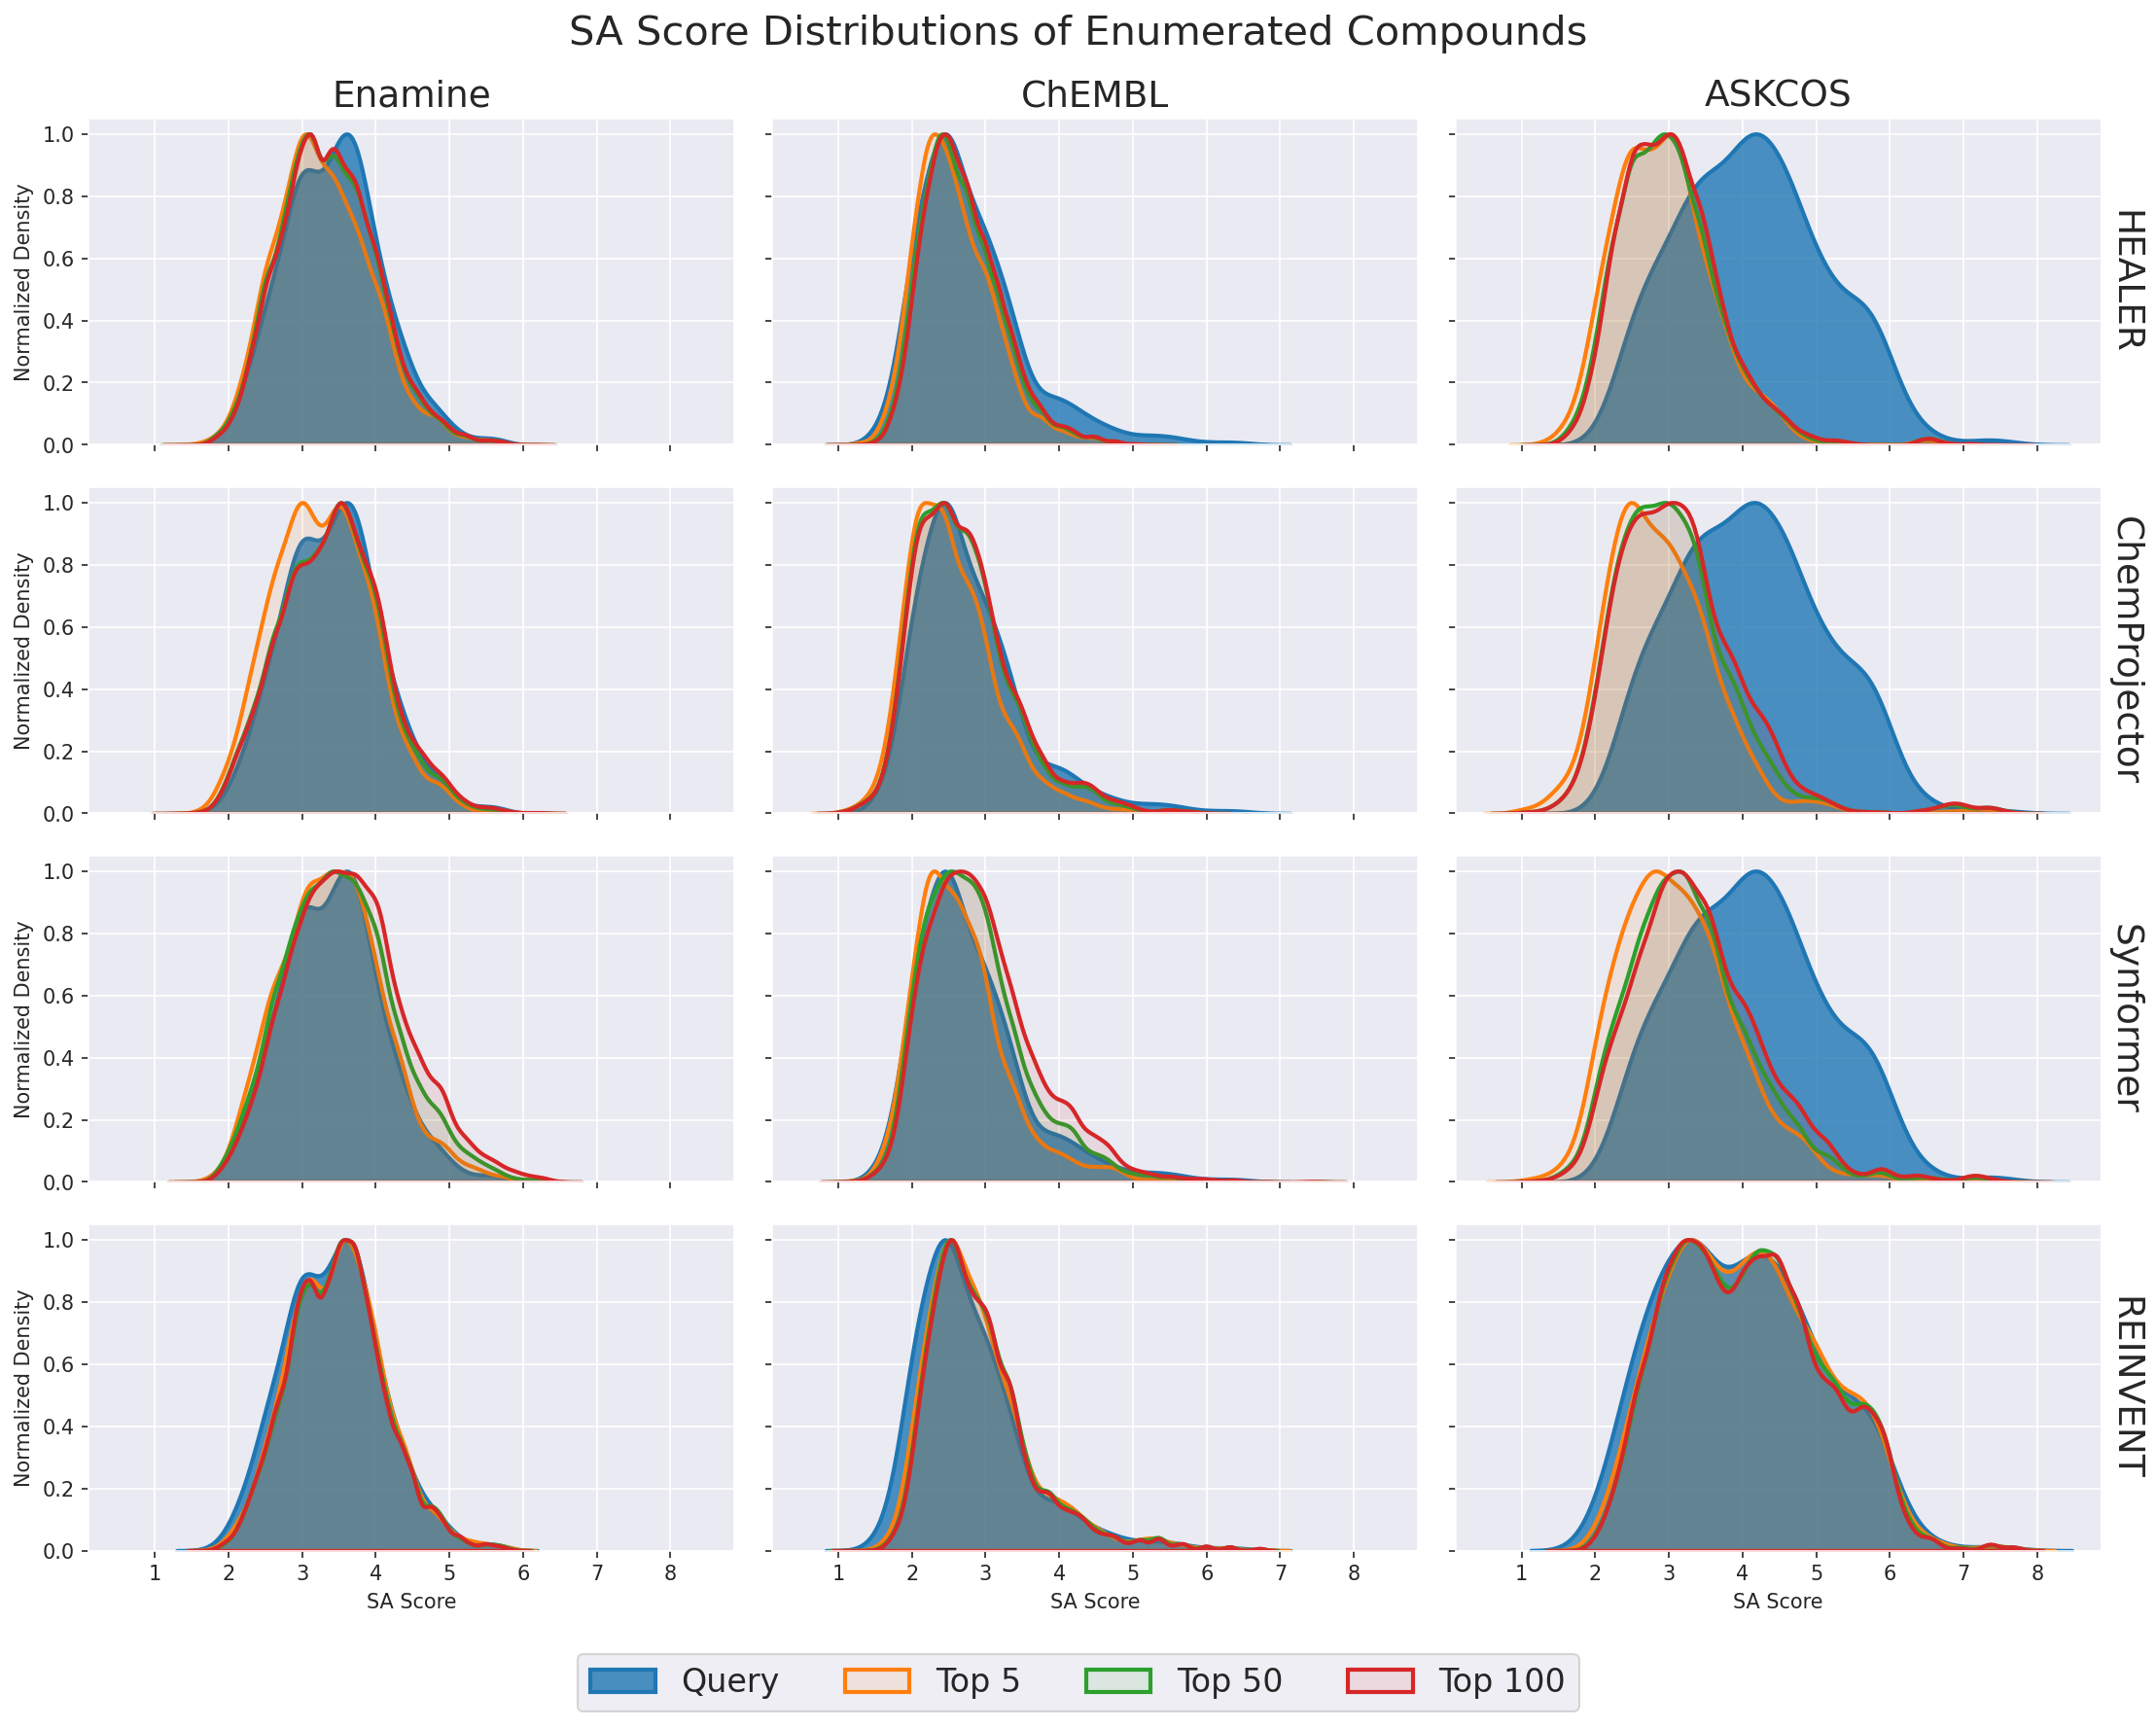

In [15]:
## plot SA score distributions
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect SA scrore arrays for each subset
    score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset,
        reinvent_enamine_subset, reinvent_chembl_subset, reinvent_askcos_subset,  # comment out to exclude
    ]
    subset_length = len(subsets)
    for subset in subsets:
        arrs = [get_top_n_subset(subset, n=0)['SA_score'].to_numpy()]
        for top_n in [5, 50, 100]:
            top_n_subset = get_top_n_subset(subset, n=top_n)
            arrs.append(top_n_subset[top_n_subset['ID'] != 'HEAL_000000']['SA_score'].to_numpy())
        score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Query', 'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(subsets) - 3)
    if subset_length == 9:
        row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer']  
    else:
        row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer'] + ['', '', 'REINVENT']

    # Create subplots
    fig, axes = plt.subplots(len(subsets)//3, 3, figsize=(15, 12), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (arrs, title, r_title) in enumerate(zip(score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(arrs, distribution_labels, ax, 'SA Score',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=False)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('SA Score Distributions of Enumerated Compounds', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])
    fname = 'benchmark/figures/sa_score_distributions_wo_reinvent.png' if subset_length==9 else 'benchmark/figures/sa_score_distributions.png'
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    fig.show()

# test significance of differences between distributions
labels = list(product(
    ['HEALER', 'ChemProjector', 'Synformer'] if subset_length==9 else ['HEALER', 'ChemProjector', 'Synformer', 'REINVENT'],
    ['Enamine', 'ChEMBL', 'ASKCOS'],
))
test_res = []
for i in range(len(labels)):
    test_res.append(f"Significance results for {labels[i][0]} on {labels[i][1]}")
    test_res.extend(significance_test(score_arrays[i], distribution_labels))
    test_res.append('')

fname = 'benchmark/figures/sa_score_significance_wo_reinvent.txt' if subset_length==9 else 'benchmark/figures/sa_score_significance.txt'
with open(fname, 'w') as f:
    f.write("\n".join(test_res))
print("\n".join(test_res))


### Diversity

/tmp/ipykernel_24293/2284694613.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


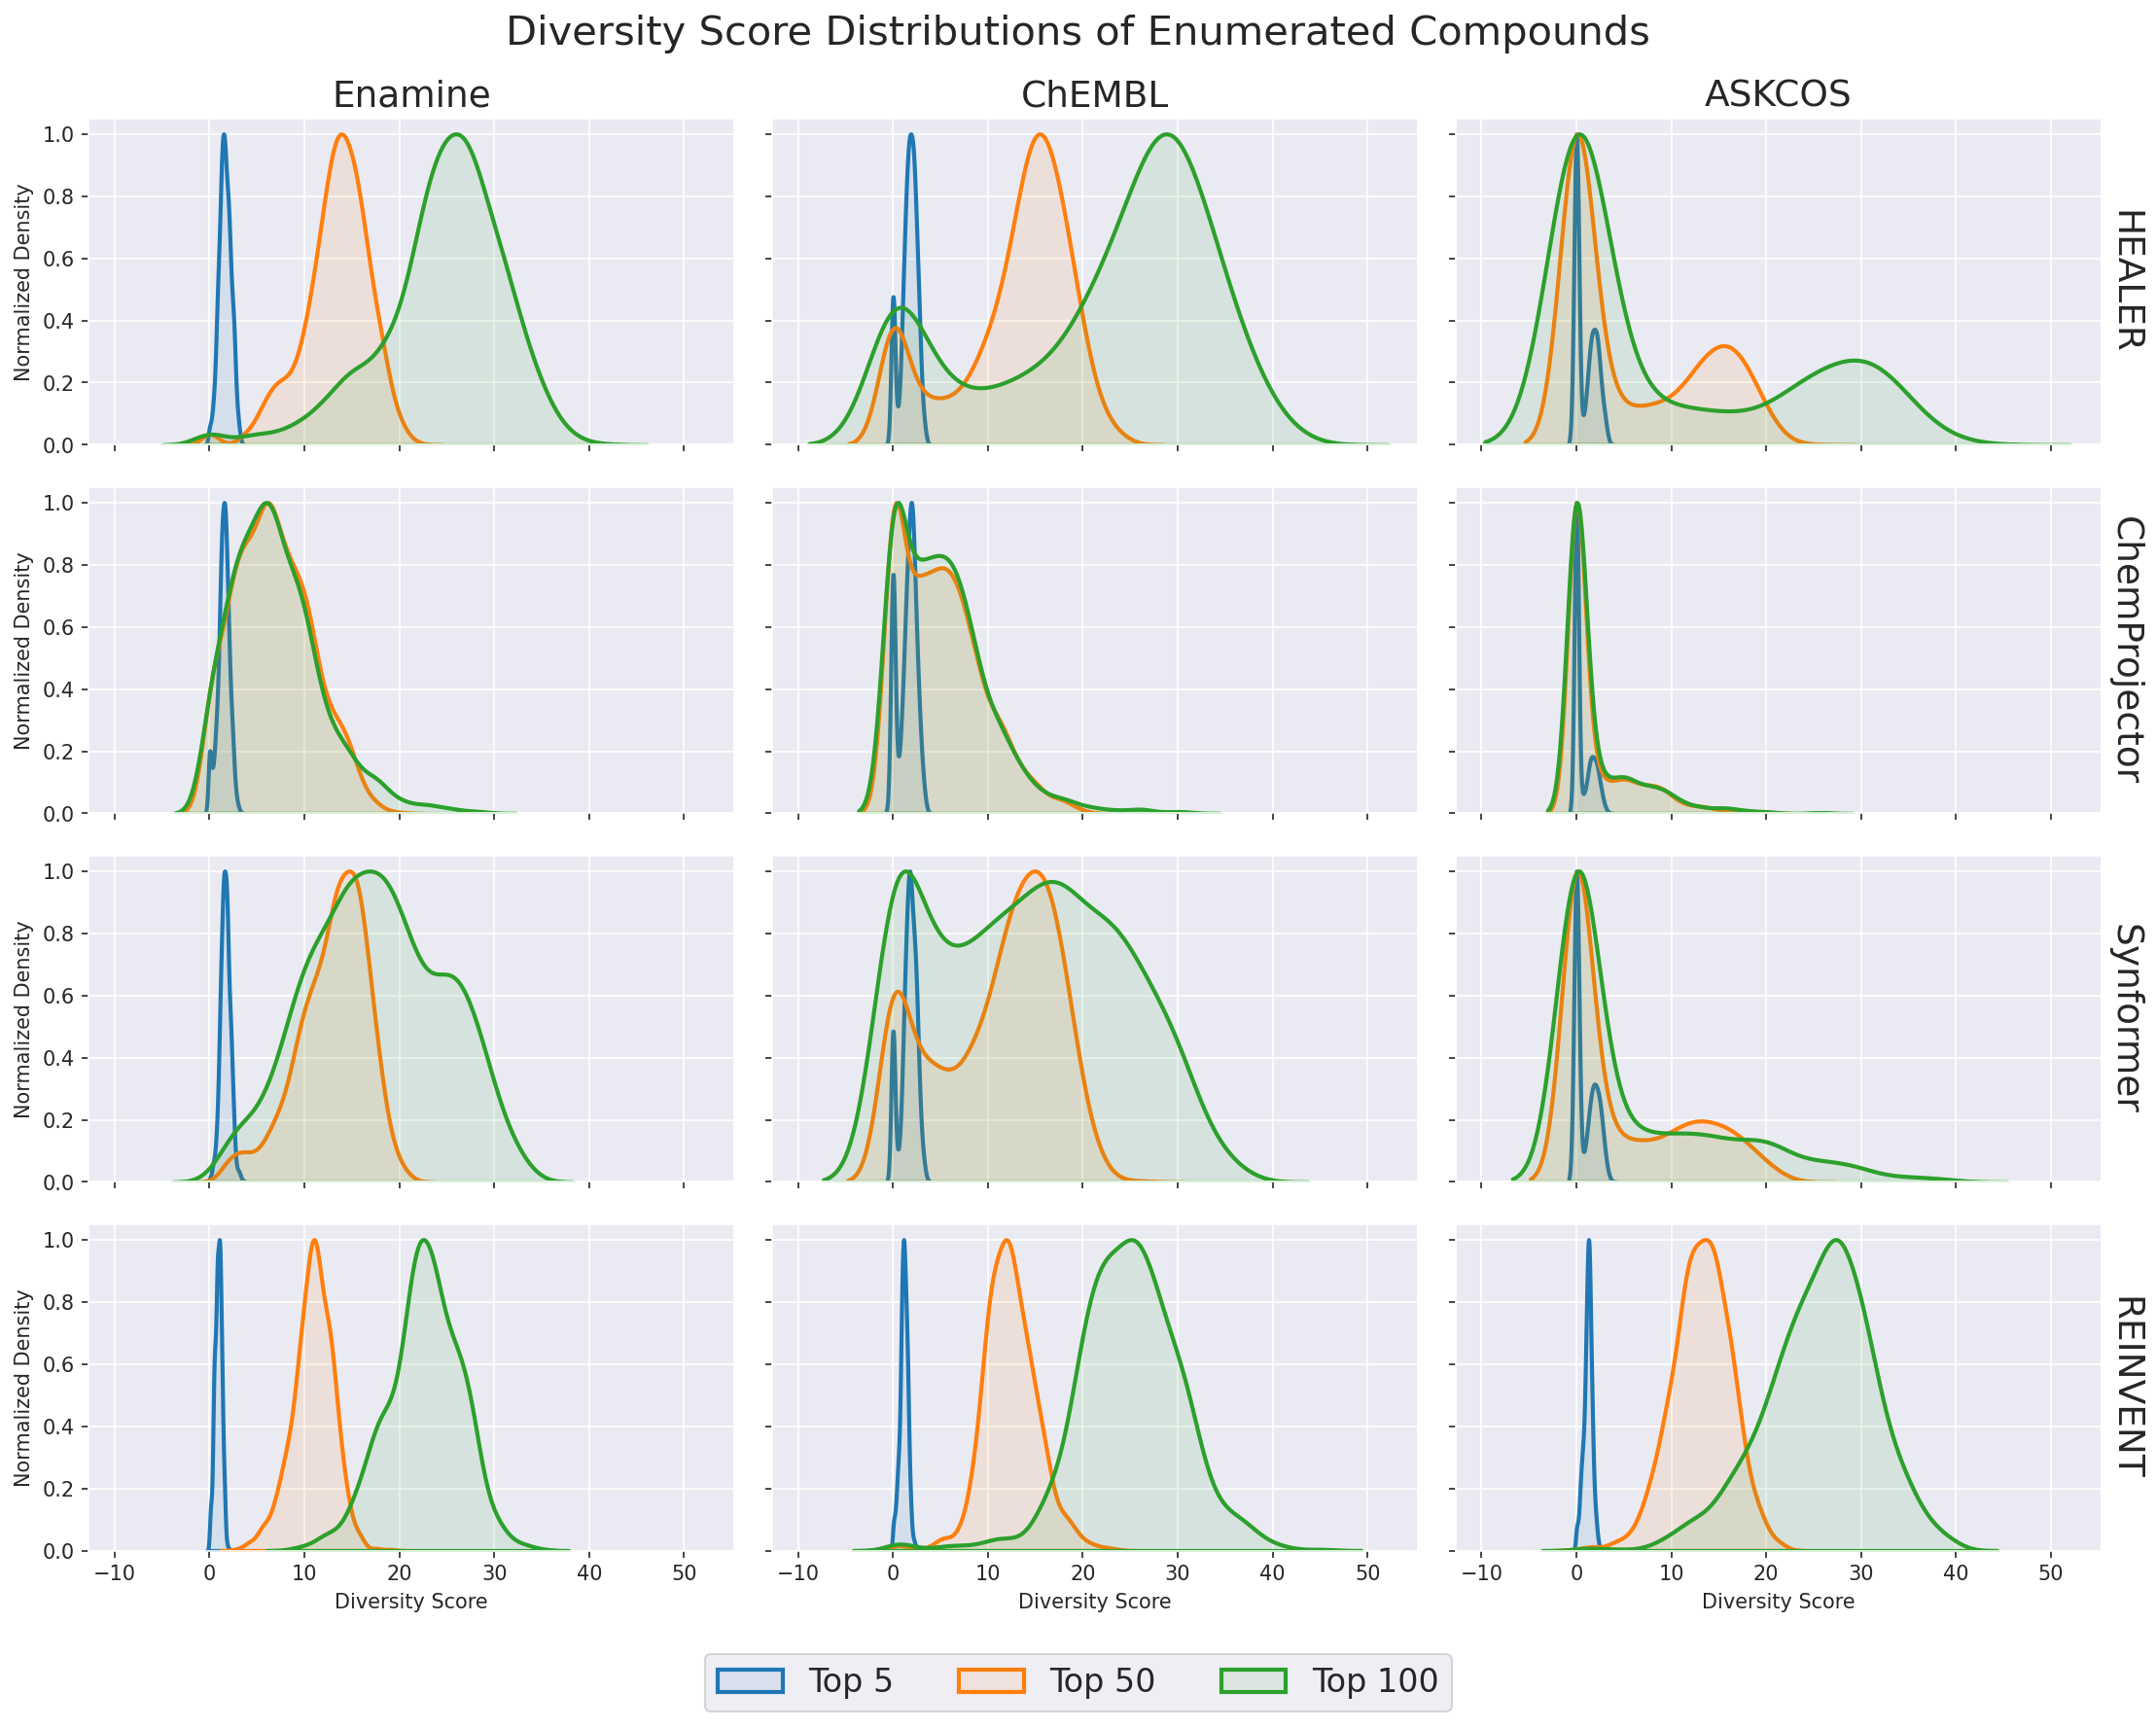

In [25]:
## plot diversity score distributions
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect Diversity score arrays for each subset
    score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset,
        reinvent_enamine_subset, reinvent_chembl_subset, reinvent_askcos_subset,
    ]
    for subset in subsets:
        arrs = []
        for top_n in [5, 50, 100]:
            arrs.append(calc_top_n_diversities(subset, n=top_n))
        score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(subsets) - 3)
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer'] + ['', '', 'REINVENT']

    # Create subplots
    fig, axes = plt.subplots(len(subsets)//3, 3, figsize=(15, 12), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (arrs, title, r_title) in enumerate(zip(score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(arrs, distribution_labels, ax, 'Diversity Score',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=False)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('Diversity Score Distributions of Enumerated Compounds', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])
    fig.savefig('benchmark/figures/diversity_score_distributions.png', dpi=300, bbox_inches='tight')
    fig.show()


### Similarity

/tmp/ipykernel_24293/104992108.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


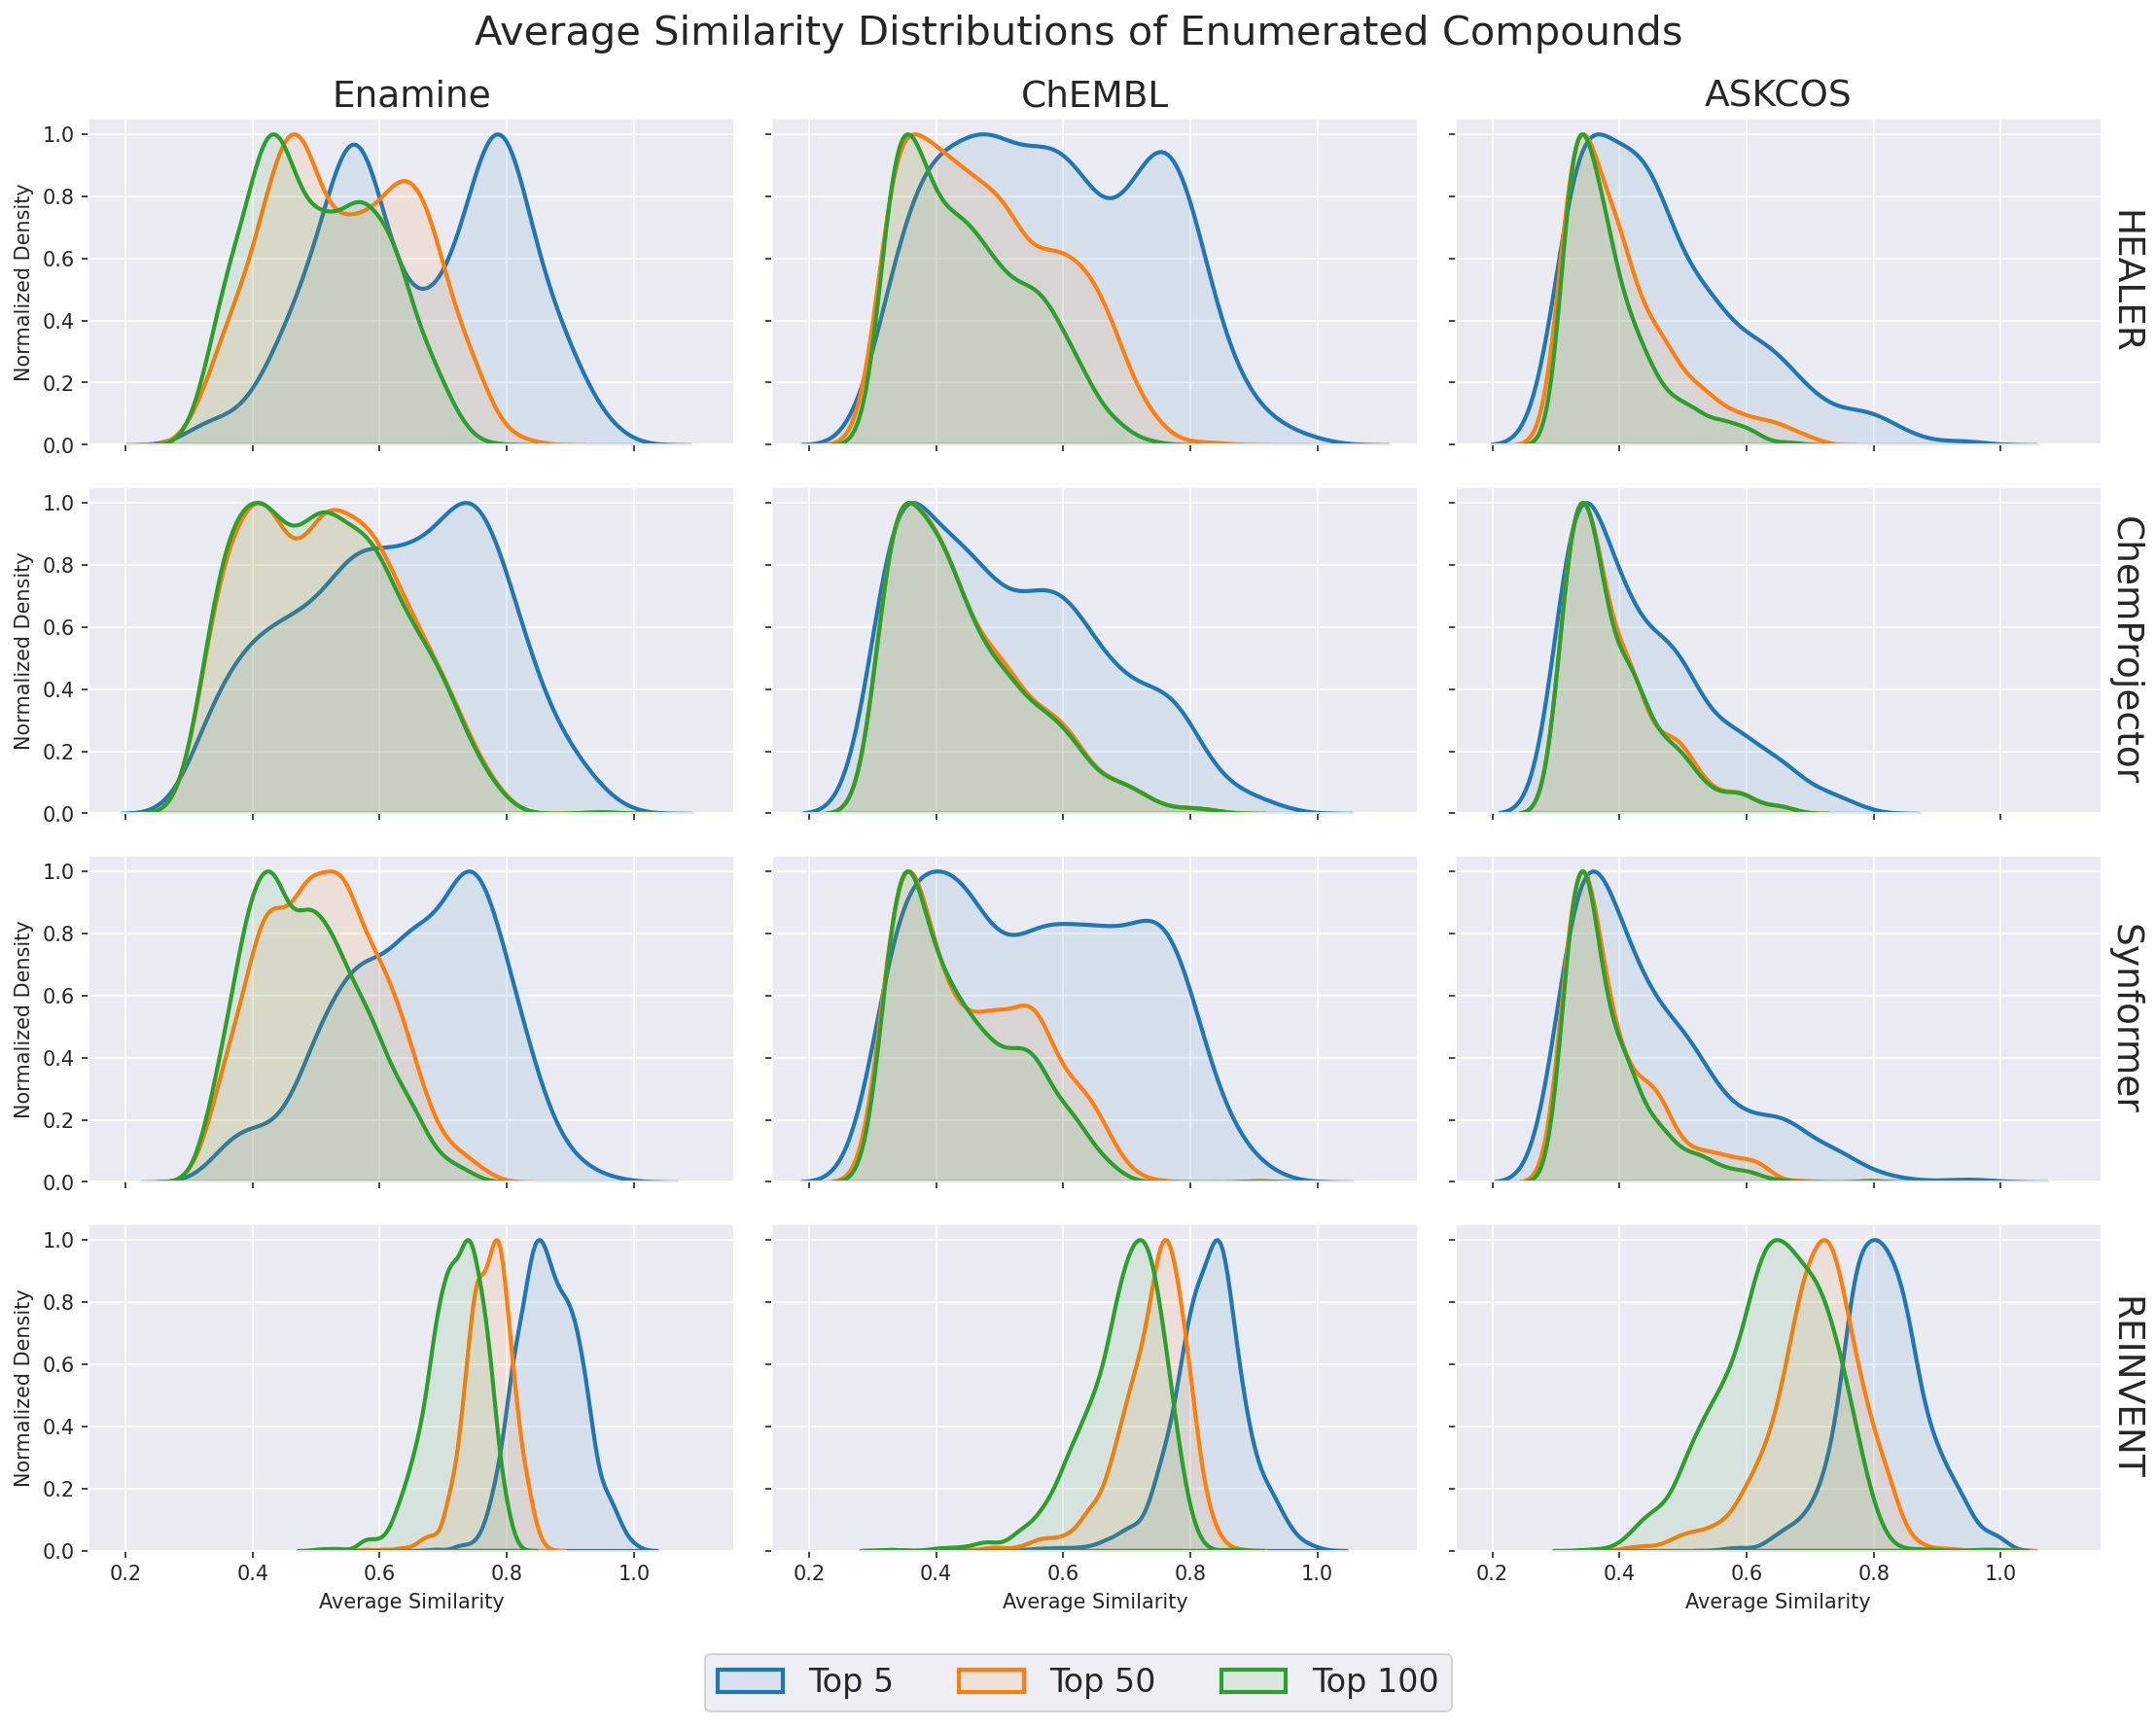

In [21]:
## plot diversity score distributions
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect Average Similarity score arrays for each subset
    score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset,
        reinvent_enamine_subset, reinvent_chembl_subset, reinvent_askcos_subset,
    ]
    for subset in subsets:
        arrs = []
        for top_n in [5, 50, 100]:
            arrs.append(calc_top_n_average_sims(subset, n=top_n))
        score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(subsets) - 3)
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer'] + ['', '', 'REINVENT']

    # Create subplots
    fig, axes = plt.subplots(len(subsets)//3, 3, figsize=(15, 12), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (arrs, title, r_title) in enumerate(zip(score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(arrs, distribution_labels, ax, 'Average Similarity',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=False)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('Average Similarity Distributions of Enumerated Compounds', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])
    fig.savefig('benchmark/figures/average_similarity_distributions.png', dpi=300, bbox_inches='tight')
    fig.show()


### Maximum Stoplight Improvements

NOTE: Stoplight scores vary between 0 and 2 where 0 is the best score and 2 is the worst. Thus, better improvements are indicated by lower Stoplight scores. In short, the lower the Stoplight score, the better the improvement.

/tmp/ipykernel_24293/1815656001.py:52: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmin(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/604840124.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


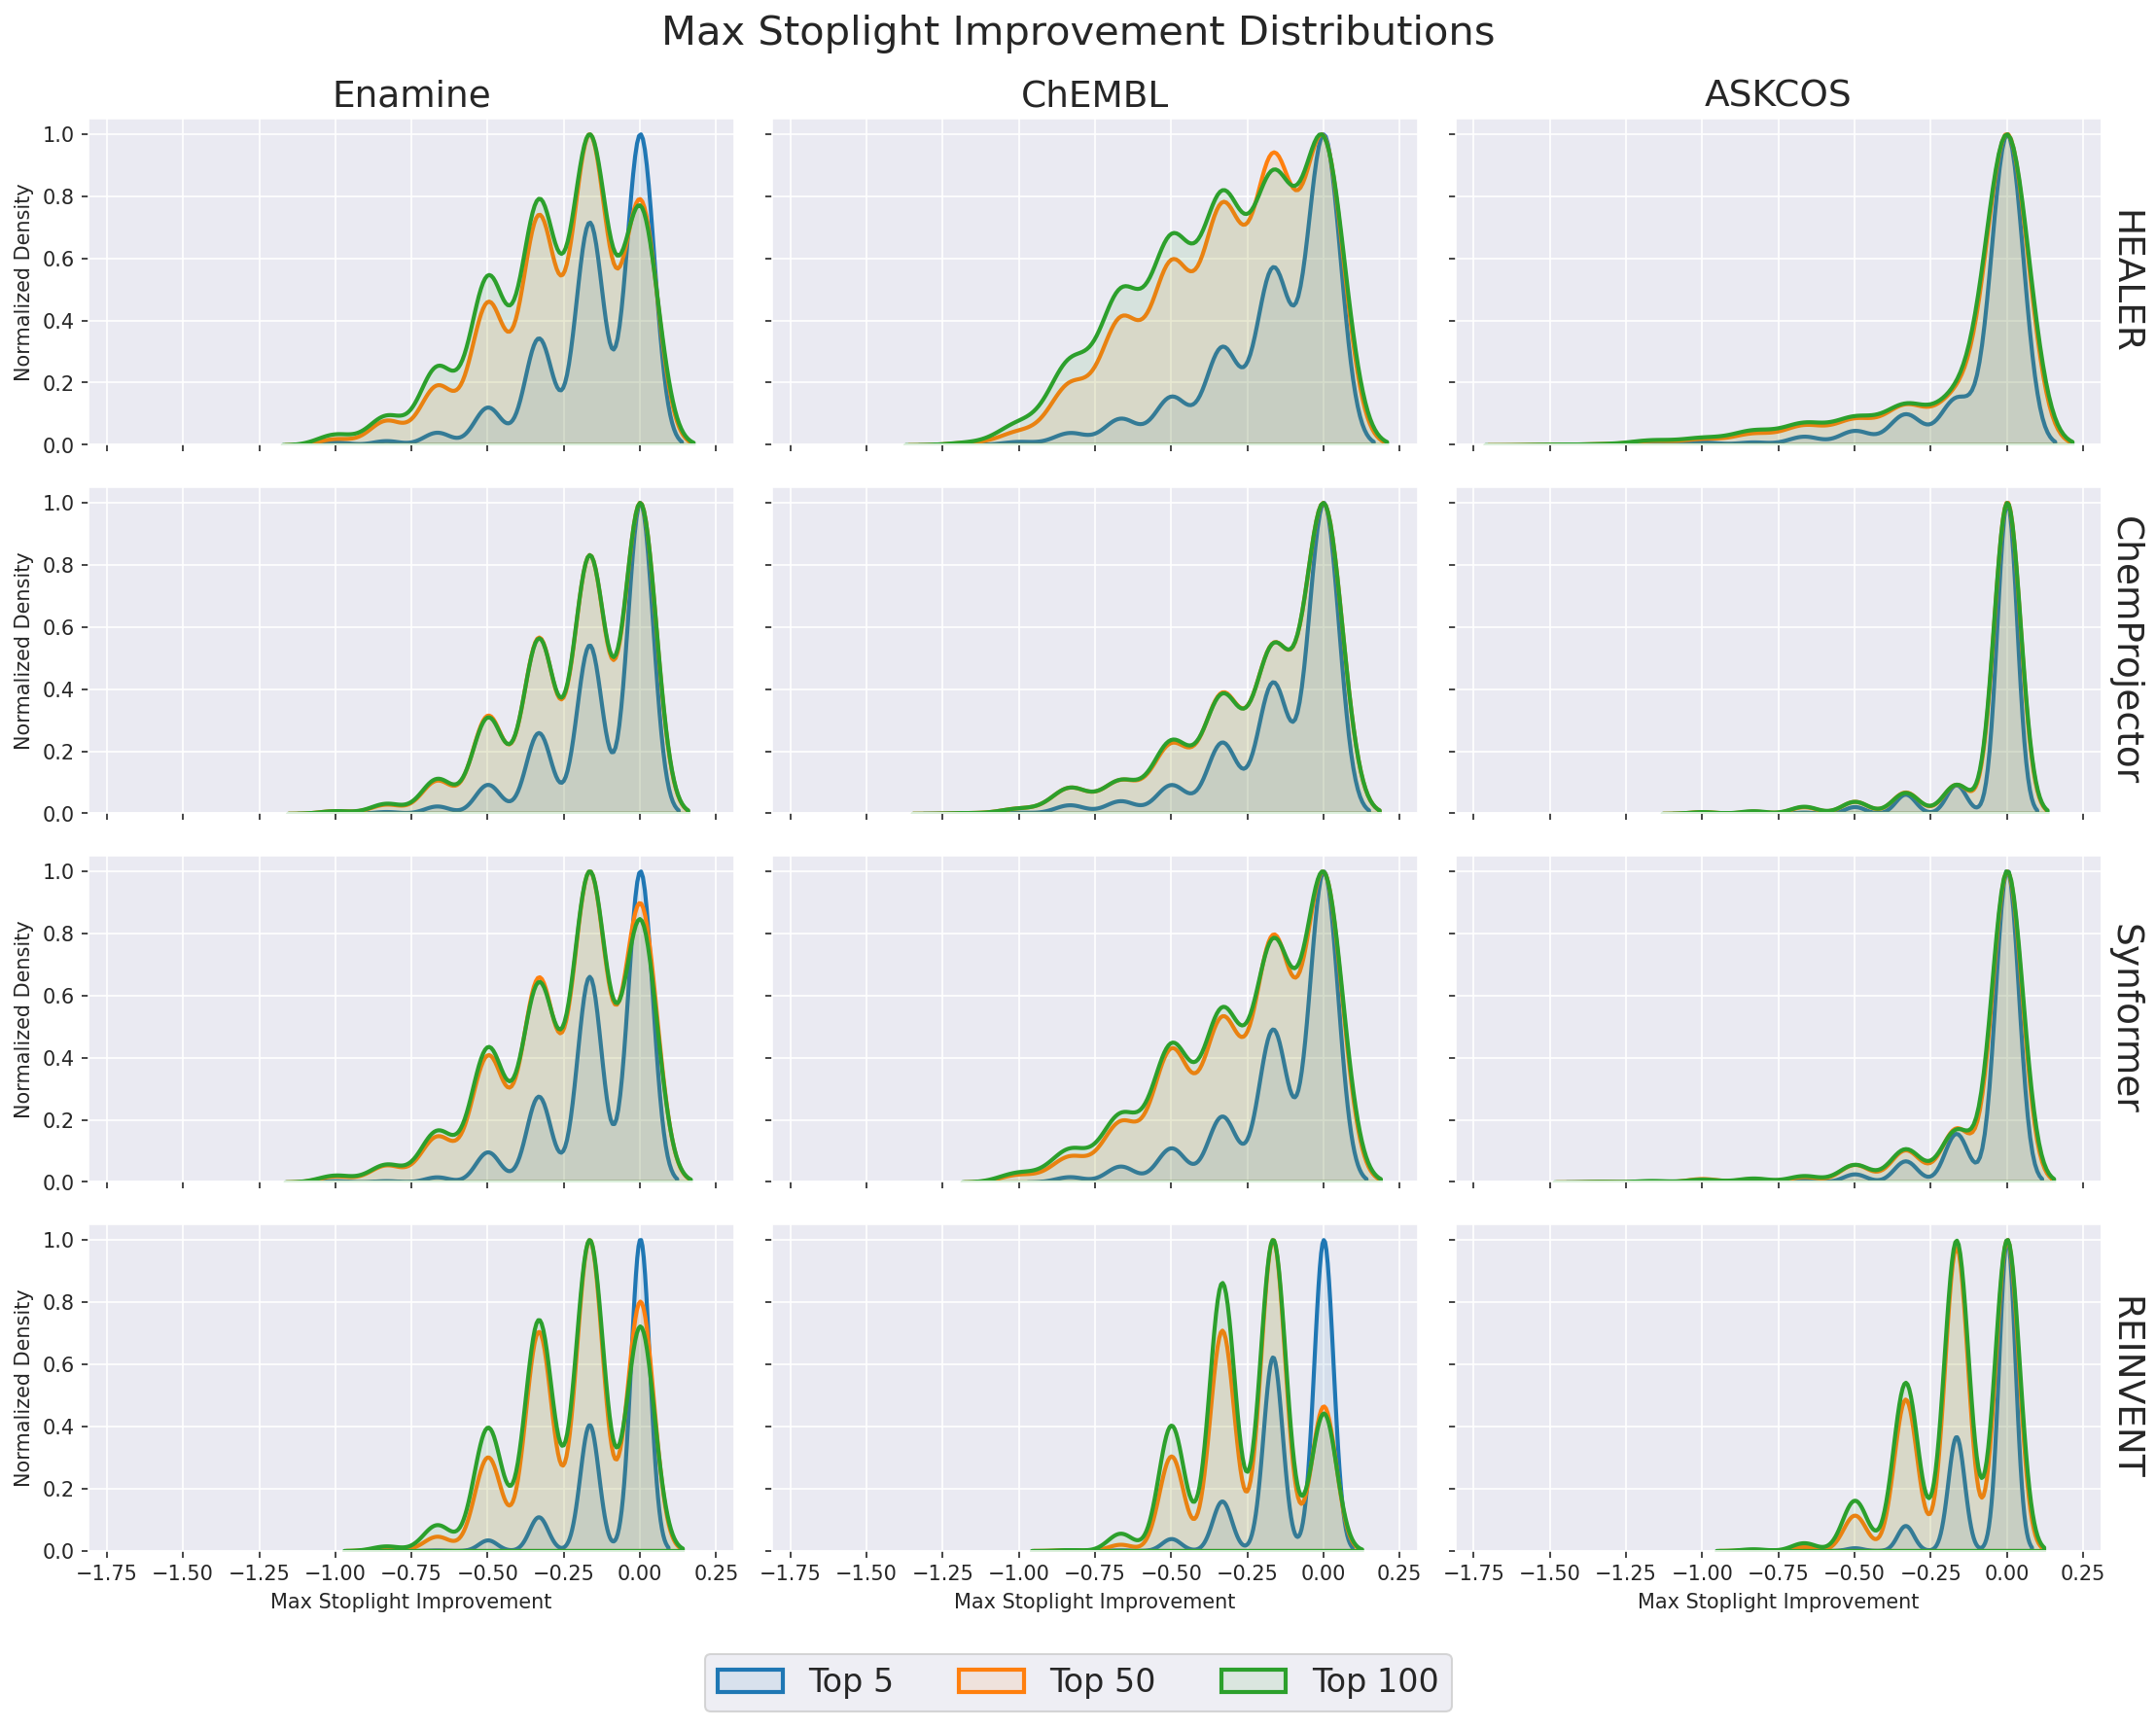

In [22]:
## plot diversity score distributions
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect Max Stoplight Improvement score arrays for each subset
    score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset,
        reinvent_enamine_subset, reinvent_chembl_subset, reinvent_askcos_subset,
    ]
    for subset in subsets:
        arrs = []
        for top_n in [5, 50, 100]:
            arrs.append(calc_top_n_max_stoplight_improvements(subset, n=top_n))
        score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(subsets) - 3)
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer'] + ['', '', 'REINVENT']

    # Create subplots
    fig, axes = plt.subplots(len(subsets)//3, 3, figsize=(15, 12), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (arrs, title, r_title) in enumerate(zip(score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(arrs, distribution_labels, ax, 'Max Stoplight Improvement',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=False)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('Max Stoplight Improvement Distributions', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])
    fig.savefig('benchmark/figures/max_stoplight_improvement_distributions.png', dpi=300, bbox_inches='tight')
    fig.show()


### Max CNS-MPO Improvements

/tmp/ipykernel_24293/1815656001.py:34: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/194683353.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


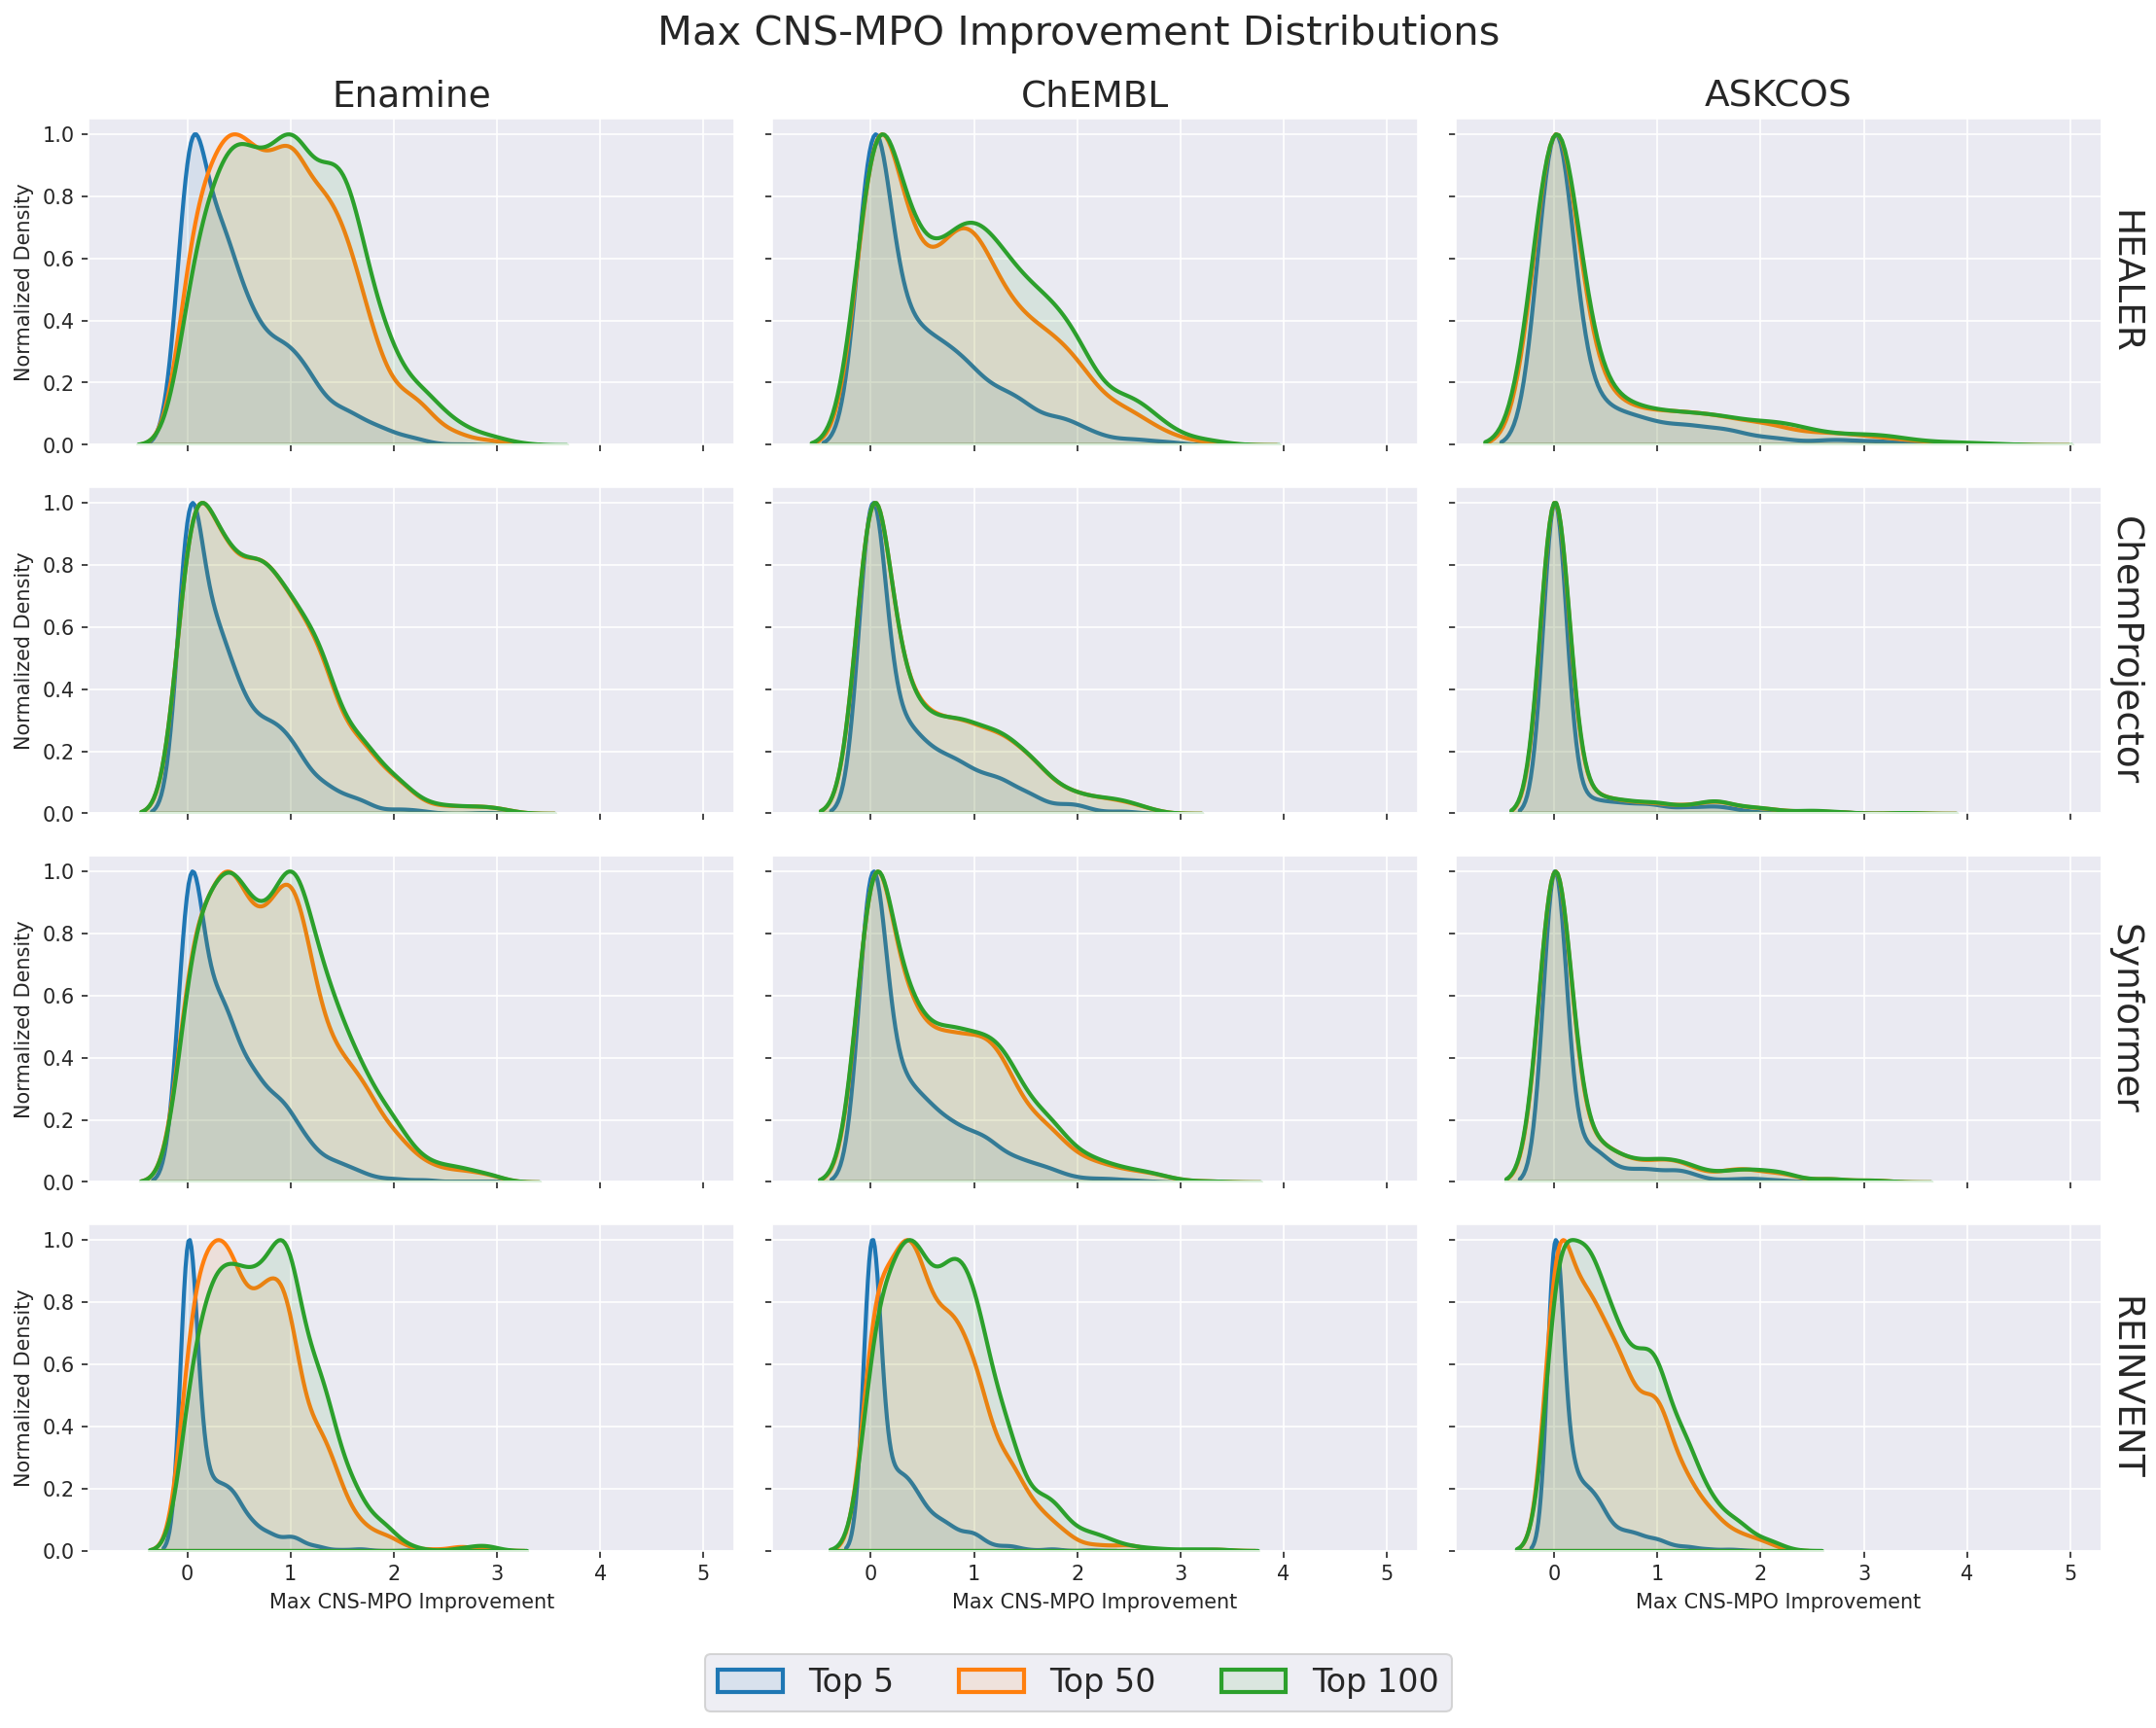

In [23]:
## plot diversity score distributions
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect Max Stoplight Improvement score arrays for each subset
    score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset,
        reinvent_enamine_subset, reinvent_chembl_subset, reinvent_askcos_subset,
    ]
    for subset in subsets:
        arrs = []
        for top_n in [5, 50, 100]:
            arrs.append(calc_top_n_max_cns_mpo_improvements(subset, n=top_n))
        score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(subsets) - 3)
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer'] + ['', '', 'REINVENT']

    # Create subplots
    fig, axes = plt.subplots(len(subsets)//3, 3, figsize=(15, 12), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (arrs, title, r_title) in enumerate(zip(score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(arrs, distribution_labels, ax, 'Max CNS-MPO Improvement',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=False)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('Max CNS-MPO Improvement Distributions', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])
    fig.savefig('benchmark/figures/max_cns_mpo_improvement_distributions.png', dpi=300, bbox_inches='tight')
    fig.show()


### Max QED Improvements

/tmp/ipykernel_24293/1815656001.py:16: RuntimeWarning: All-NaN axis encountered
  lambda x: np.nanmax(x - x.iloc[0]) if len(x) > 1 else 0
/tmp/ipykernel_24293/1863186133.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


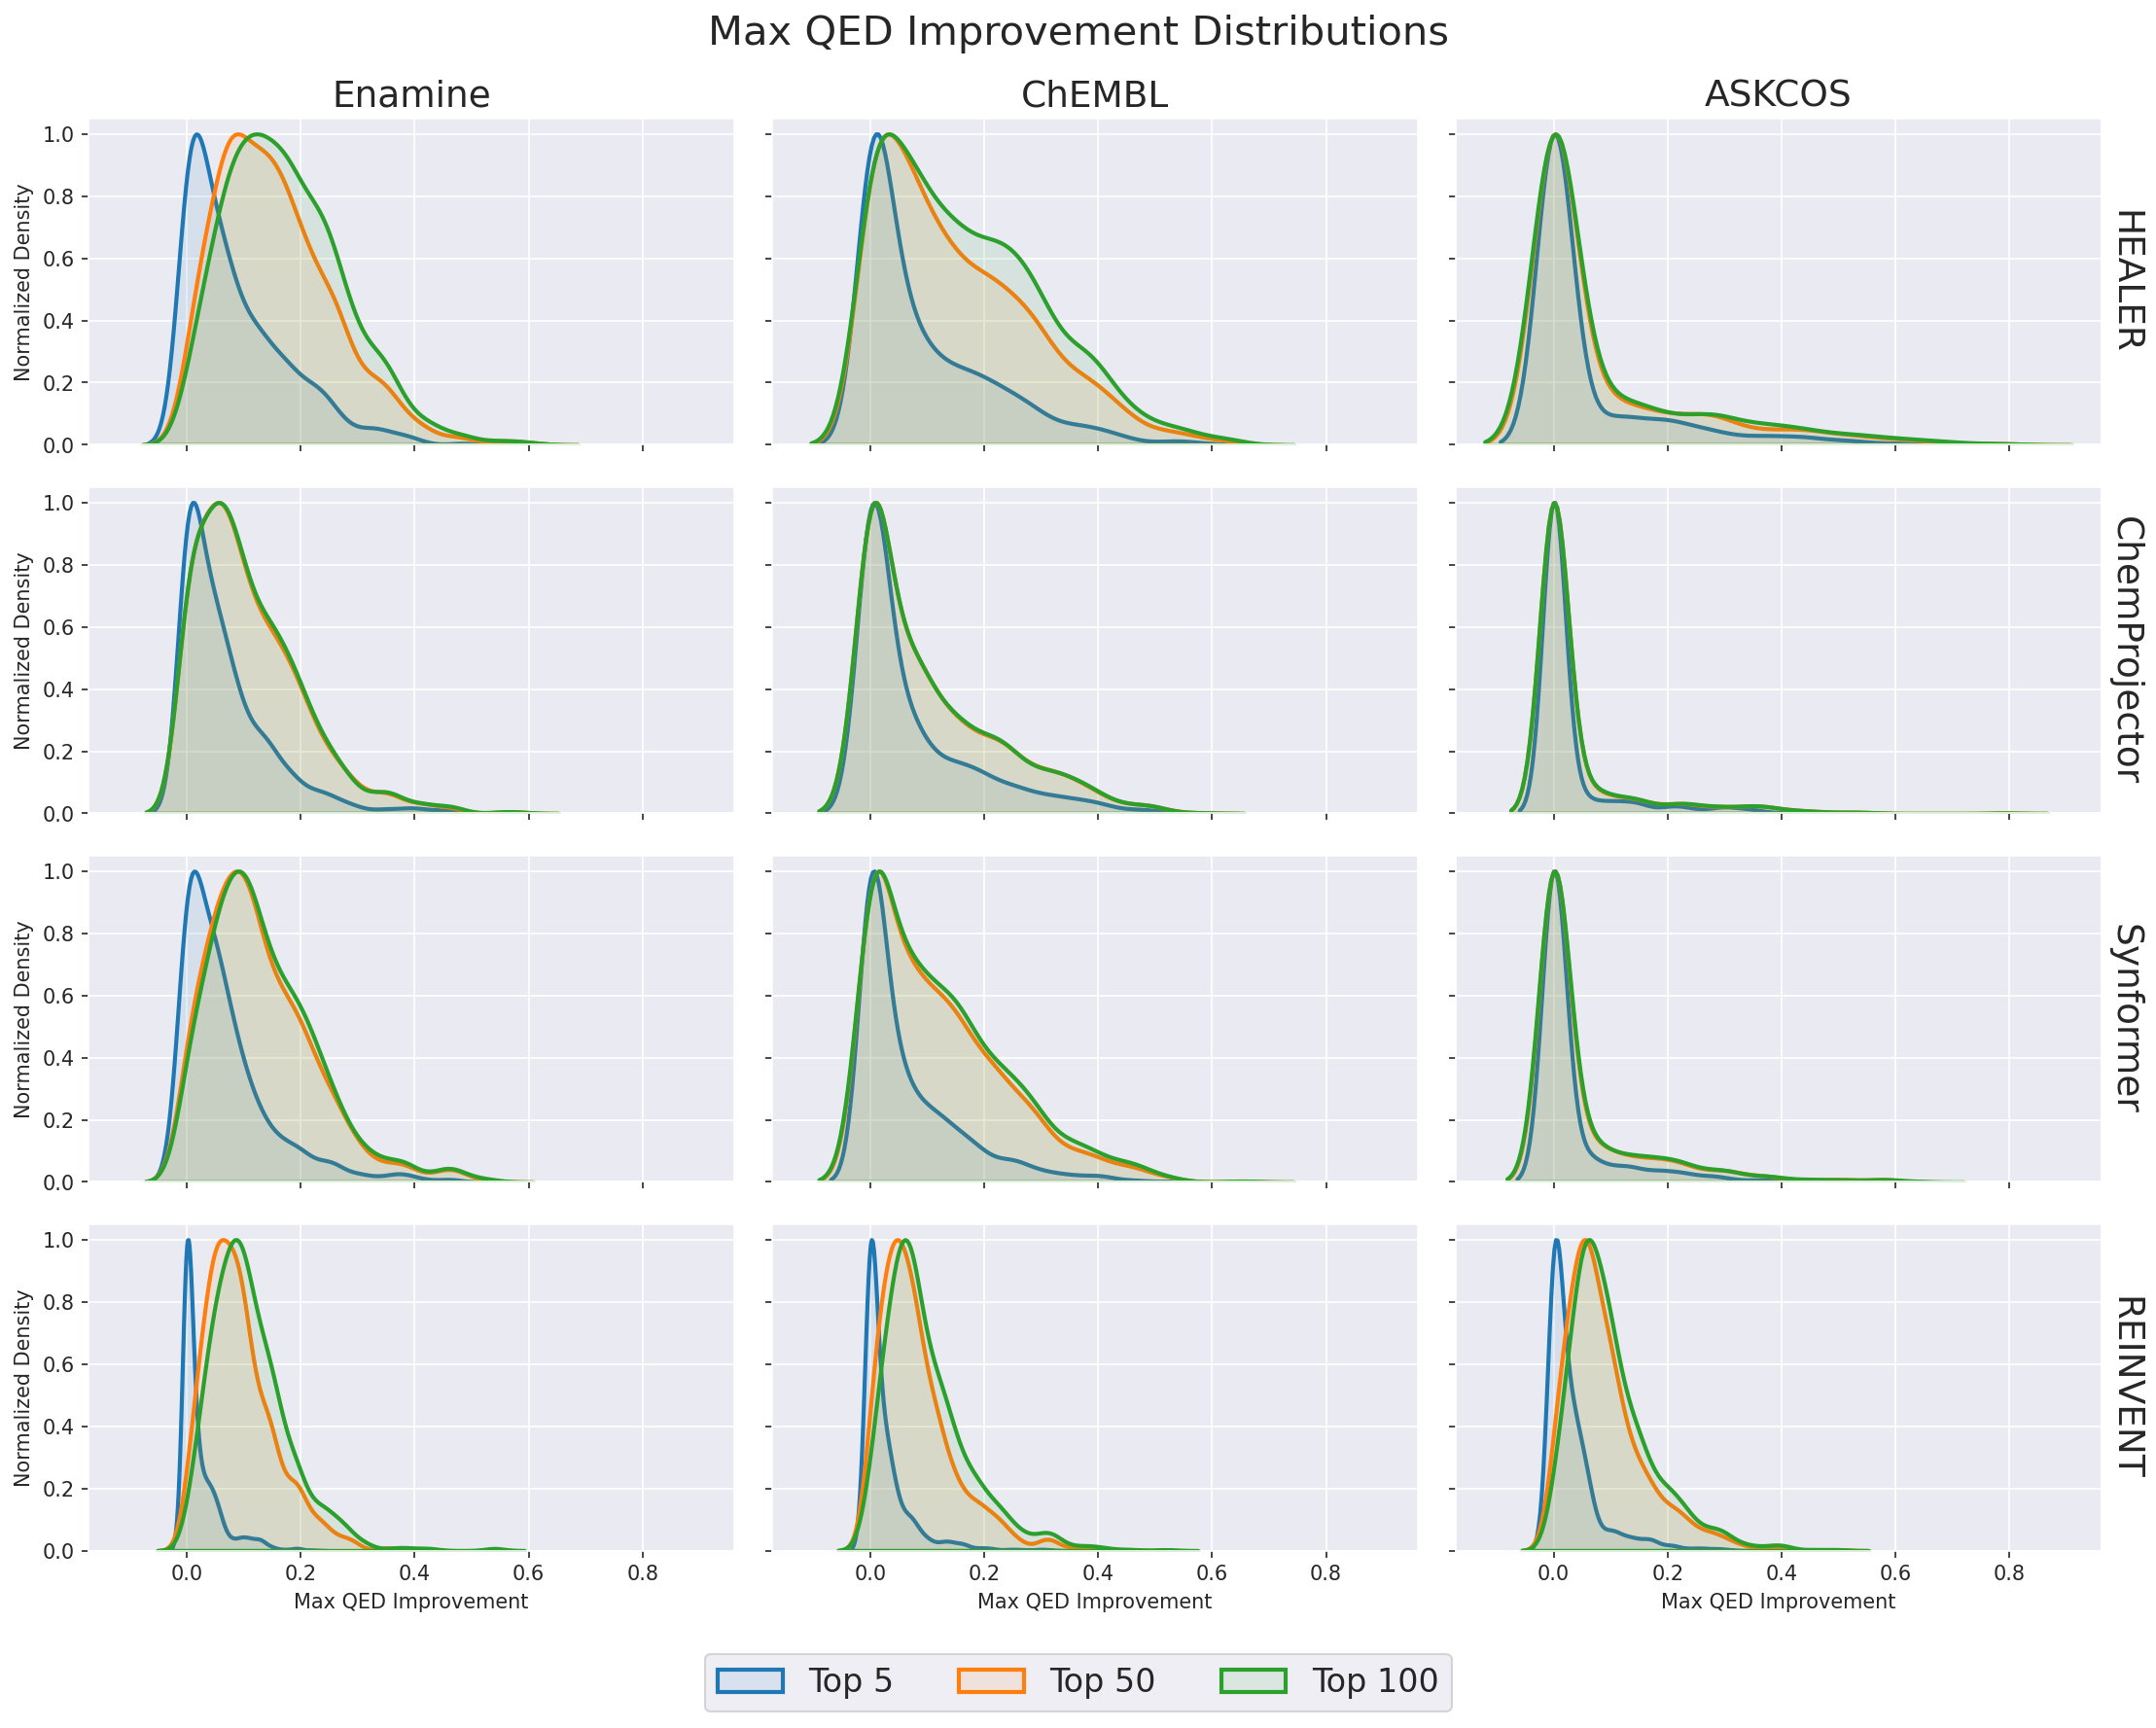

In [24]:
## plot diversity score distributions
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect Max Stoplight Improvement score arrays for each subset
    score_arrays = []
    subsets = [
        healer_enamine_subset, healer_chembl_subset, healer_askcos_subset,
        chemprojector_enamine_subset, chemprojector_chembl_subset, chemprojector_askcos_subset,
        synformer_enamine_subset, synformer_chembl_subset, synformer_askcos_subset,
        reinvent_enamine_subset, reinvent_chembl_subset, reinvent_askcos_subset,
    ]
    for subset in subsets:
        arrs = []
        for top_n in [5, 50, 100]:
            arrs.append(calc_top_n_max_qed_improvements(subset, n=top_n))
        score_arrays.append(arrs)

    # Define labels and titles for the plots
    distribution_labels = [
        'Top 5', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(subsets) - 3)
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer'] + ['', '', 'REINVENT']

    # Create subplots
    fig, axes = plt.subplots(len(subsets)//3, 3, figsize=(15, 12), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (arrs, title, r_title) in enumerate(zip(score_arrays, titles, row_titles)):
        ax = axes[i]
        plot_distributions(arrs, distribution_labels, ax, 'Max QED Improvement',
                           normalize_y=True, title=title, sec_ylabel=r_title, annotate_n=False)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('Max QED Improvement Distributions', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])
    fig.savefig('benchmark/figures/max_qed_improvement_distributions.png', dpi=300, bbox_inches='tight')
    fig.show()


## Drug-Likeness Analysis

Interactive exploration of enumerated compounds' drug-likeness properties and molecular structure visualization. This part is performed only for the HEALER method. The examples are selected based on the drug-likeness profiles of the enumerated compounds, specifically focusing on red-to-green Stoplight examples where the compounds show significant improvements in drug-likeness scores.

In [57]:
## Select drug-likeliness profiles to display next
enamine_group_names = [56]     # 56, 550, 107, 270
chembl_group_names = [564]     # 789, 564, 250, 332
askcos_group_names = [117]     # 117, 562, 143

/tmp/ipykernel_24846/3095407314.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.075, 0.92, 1])
/tmp/ipykernel_24846/3095407314.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


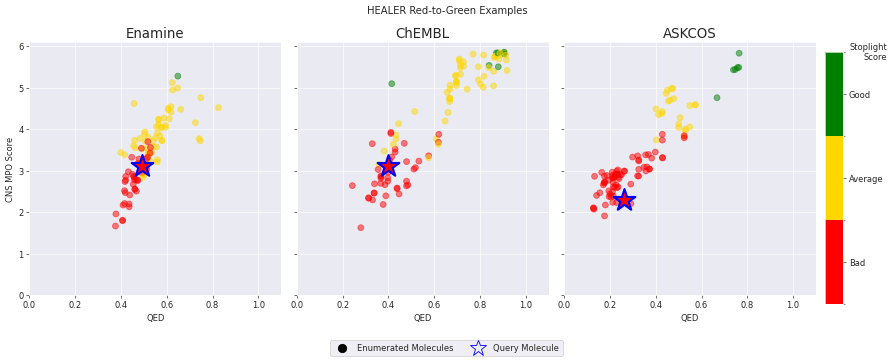

In [60]:
## plot drug-likeliness examples
# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    # Collect red-to-green examples of drug-likeliness profiles
    groups = []
    for i in range(len(enamine_group_names)):
        enamine_group = healer_enamine_subset.groupby(by='df_id').get_group(enamine_group_names[i])
        chembl_group = healer_chembl_subset.groupby(by='df_id').get_group(chembl_group_names[i])
        askcos_group = healer_askcos_subset.groupby(by='df_id').get_group(askcos_group_names[i])
        groups.extend([enamine_group, chembl_group, askcos_group])

    # Define labels and titles for the plots
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * (len(groups) - 3)

    # Colorbar mappable
    stoplight_cmap = mpl.colors.ListedColormap(['red', 'gold', 'green'])
    stoplight_norm = mpl.colors.BoundaryNorm(np.linspace(0, 3, 4), stoplight_cmap.N)
    sm = mpl.cm.ScalarMappable(cmap=stoplight_cmap, norm=stoplight_norm)

    # Create subplots
    fig, axes = plt.subplots(len(groups)//3, 3, figsize=(15, len(groups)//3 *6), dpi=60, sharex=True, sharey='all')
    axes = axes.flatten()
    
    for i, (group, title) in enumerate(zip(groups, titles)):
        ax = axes[i]
        plot_drug_likeliness_profiles(data=group, ax=ax, include_colorbar=False)
        ax.set_title(title, fontsize=16)
        if i % 3 != 0:
            ax.set_ylabel('')
        if i < (len(axes) - 3):
            ax.set_xlabel('')
        if ax.get_legend():
            ax.legend_.remove()

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([0.5, 1.5, 2.5])
    cbar.set_ticklabels(['Bad', 'Average', 'Good'])
    cbar.set_label('Stoplight\nScore', loc='top', rotation=0)
    cbar.ax.yaxis.label.set_verticalalignment('center')

    fig.legend(labels=['Enumerated Molecules', 'Query Molecule'],
               handles=[mpl.lines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10),
                        mpl.lines.Line2D([], [], color='blue', marker='*', linestyle='None', fillstyle='none', markersize=20)],
               loc='lower center', ncol=2, frameon=True)
    
    fig.suptitle('HEALER Red-to-Green Examples')
    fig.tight_layout(rect=[0, 0.075, 0.92, 1])
    group_names = '_'.join([f"{group.df_id.iloc[0]}" for group in groups])
    fig.savefig(f'benchmark/figures/healer_r2g_examples_{group_names}.png', dpi=300, bbox_inches='tight')
    fig.show()


In [10]:
# configure dataset and group for red-to-green examples
# Some preselected red-to-green examples:
# enamine: 56, 550, 107, 270; chembl: 789, 564, 250, 332; askcos: 117, 562, 143
ds_name = 'enamine'
group_id = 107
n_enumerations = 100
qed_cutoff = 0.4
cns_mpo_cutoff = 4.0
save = False

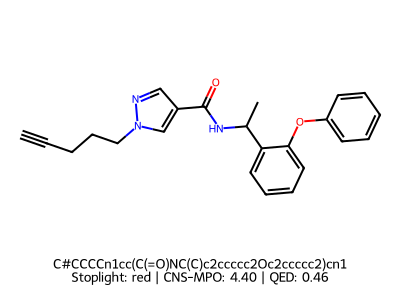

In [13]:
## Display the query molecule and enumerated products
# Combine the group data with the BB data
if ds_name == 'enamine':
    healer_group = healer_enamine_subset.groupby(by='df_id').get_group(group_id)
    healer_group = pd.merge(
        healer_group, 
        pd.read_csv('benchmark/results/healer/enamine_1k_random_enums.csv', 
                    usecols=lambda x: x=='Product' or 'BB' in x, keep_default_na=False, dtype=str),
        on='Product', how='left'
    )
elif ds_name == 'chembl':
    healer_group = healer_chembl_subset.groupby(by='df_id').get_group(group_id)
    healer_group = pd.merge(
        healer_group, 
        pd.read_csv('benchmark/results/healer/chembl_1k_random_enums.csv', 
                    usecols=lambda x: x=='Product' or 'BB' in x, keep_default_na=False, dtype=str),
        on='Product', how='left'
    )
elif ds_name == 'askcos':
    healer_group = healer_askcos_subset.groupby(by='df_id').get_group(group_id)
    healer_group = pd.merge(
        healer_group, 
        pd.read_csv('benchmark/results/healer/askcos_unsynthesizable_1k_random_enums.csv', 
                    usecols=lambda x: x=='Product' or 'BB' in x, keep_default_na=False, dtype=str),
        on='Product', how='left'
    )
healer_group = healer_group.drop_duplicates(subset='Product').reset_index(drop=True)

# Display the query molecule
query_img = Draw.MolsToGridImage([Chem.MolFromSmiles(healer_group.Product.values[0])], 
                                 molsPerRow=1, useSVG=True, subImgSize=(400, 300), 
                                 legends=[f"{healer_group.Product.values[0]}\n" 
                                          f"Stoplight: {healer_group.stoplight_color.values[0]} | "
                                          f"CNS-MPO: {healer_group.cns_mpo_score.values[0]:.2f} | "
                                          f"QED: {healer_group.qed.values[0]:.2f}"])
display(query_img)

# Display the enumerated products with the given cutoffs
svgs = []
n_enumerations = n_enumerations if n_enumerations < len(healer_group) else len(healer_group)
for i in range(1, n_enumerations):
    if healer_group.cns_mpo_score.values[i] >= cns_mpo_cutoff and healer_group.qed.values[i] >= qed_cutoff:
        legend = (
            f"{healer_group.Product.values[i]}\n"
            f"Tanimoto: {healer_group.Similarity_to_query.values[i]:.2f} | "
            f"Stoplight: {healer_group.stoplight_color.values[i]} | "
            f"CNS-MPO: {healer_group.cns_mpo_score.values[i]:.2f} | "
            f"QED: {healer_group.qed.values[i]:.2f}"
        )
        bb_cols = [col for col in healer_group.columns if 'BB' in col]
        bbs = [Chem.MolFromSmiles(healer_group[col].values[i]) for col in bb_cols if healer_group[col].values[i]]
        svg = utils.get_svg_mol_with_bbs(
            mol=healer_group.Product.values[i],
            bbs=bbs, legend=legend,
            width=350, height=200,
        )
        svgs.append(svg)
html_mol_grid = display_svg_grid(svgs, ncols=3)
display(html_mol_grid)

if save:
    with open(f'benchmark/figures/{ds_name}_group_{group_id}_enumerations.html', 'w') as f:
        f.write(query_img.data)
        f.write("\n")
        f.write(html_mol_grid.data)


In [21]:
svgs = []
n_enumerations = n_enumerations if n_enumerations < len(healer_group) else len(healer_group)
for i in range(n_enumerations):
    if healer_group.cns_mpo_score.values[i] >= cns_mpo_cutoff and healer_group.qed.values[i] >= qed_cutoff:
        bb_cols = [col for col in healer_group.columns if 'BB' in col]
        bbs = [Chem.MolFromSmiles(healer_group[col].values[i]) for col in bb_cols if healer_group[col].values[i]]
        svg = utils.get_svg_mol_with_bbs(
            mol=healer_group.Product.values[i],
            bbs=[],
            width=350, height=200,
        )
        svgs.append(svg)

for i, svg in enumerate(svgs):
    with open(f'scratch/tmp{i}.svg', 'w') as f:
        f.write(display_svg_mol(svg).data)
